# DC Housing Market Analysis: Exploratory Data Analysis

## 1. Introduction and Setup

-   **Purpose**: This analysis explores the DC housing market and
    related economic indicators to understand market dynamics, identify
    key relationships, and prepare features for predictive modeling.
-   **Data**: Monthly economic and housing data for Washington DC from
    January 2000 to December 2024.
-   **Key Questions**:
    -   What factors influence DC housing prices?
    -   How have housing prices evolved through different economic
        cycles?
    -   Which variables lead or lag housing price changes?
    -   What features would be most valuable for forecasting?

In [25]:
# Import libraries (consolidate all imports here)
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from datetime import datetime
import os
import json
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import pickle

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create directories for saving visualizations
os.makedirs('outputs/EDA', exist_ok=True)
print("Output directory set to: outputs/EDA")

Output directory set to: outputs/EDA


## 2. Data Loading and Initial Examination

### 2.1 Load and Prepare Data

In [2]:
# Load the processed dataset
df = pd.read_csv('dc_economic_monthly_dataframe.csv')

# Convert Date column to datetime and set as index for time series analysis
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Display basic information
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Duration: {((df.index.max() - df.index.min()).days / 365.25):.1f} years")

Dataset dimensions: 300 rows × 13 columns
Time period: January 2000 to December 2024
Duration: 24.9 years


### 2.2 Data Dictionary

Create a data dictionary to clearly explain all variables:

| Variable                | Description                  | Unit                 | Source          |
|-------------------------|------------------------------|----------------------|-----------------|
| ZHVI                    | Zillow Home Value Index      | USD                  | Zillow          |
| Unemployment_Rate       | DC unemployment rate         | %                    | BLS             |
| CPI                     | Consumer Price Index         | Index (1982-84=100)  | BLS             |
| Interest_Rate           | Federal funds rate           | %                    | Federal Reserve |
| Mortgage_Rate           | 30-year fixed mortgage rate  | %                    | Freddie Mac     |
| GDP_Growth              | DC GDP quarterly growth rate | %                    | BEA             |
| Median_Household_Income | DC median household income   | USD                  | Census          |
| Population              | DC population                | Thousands            | Census          |
| Poverty_Rate            | DC poverty rate              | %                    | Census          |
| Marriage_Rate           | DC marriage rate             | Per 1,000 population | CDC             |
| Divorce_Rate            | DC divorce rate              | Per 1,000 population | CDC             |

### 2.3 Check for Missing Values and Data Quality

In [3]:
# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\nMissing values found in:")
    print(missing[missing > 0])
else:
    print("\nNo missing values in the dataset")

# Display the first few rows to verify data structure
df.head()


No missing values in the dataset


,Year,Month,Unemployment_Rate,CPI,Interest_Rate,Mortgage_Rate,ZHVI,GDP_Growth,Median_Household_Income,Population,Poverty_Rate,Marriage_Rate,Divorce_Rate
Date,,,,,,,,,,,,,
2000-01-01,2000,1,5.70,169.80,5.45,8.21,179200.93,1.50,41220.00,572.05,17.50,3.92,3.36
2000-02-01,2000,2,5.70,171.50,5.73,8.32,179346.63,1.50,41771.03,572.05,17.50,3.92,3.20
2000-03-01,2000,3,5.70,173.20,5.85,8.24,179615.18,6.89,42158.65,572.05,17.50,4.41,3.20
2000-04-01,2000,4,5.60,172.85,6.02,8.15,180223.23,8.59,42447.39,572.05,17.50,4.90,3.04
2000-05-01,2000,5,5.60,172.50,6.27,8.52,181147.58,7.50,42614.02,572.05,17.50,5.39,3.04


## 3. Descriptive Statistics and Distributions

### 3.1 Statistical Summary

In [4]:
# Generate comprehensive descriptive statistics
desc_stats = df.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).T

# Add additional statistics
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['coef_var'] = desc_stats['std'] / desc_stats['mean'] * 100  # Coefficient of variation
desc_stats['skewness'] = df.skew()
desc_stats['kurtosis'] = df.kurtosis()

# Display the enhanced statistics
print("Enhanced Descriptive Statistics:")
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max', 'range', 'coef_var', 'skewness', 'kurtosis']]
display(desc_stats)

Enhanced Descriptive Statistics:


,count,mean,std,min,10%,25%,50%,75%,90%,max,range,coef_var,skewness,kurtosis
Year,300.00,2012.00,7.22,2000.00,2002.00,2006.00,2012.00,2018.00,2022.00,2024.00,24.00,0.36,0.00,-1.20
Month,300.00,6.50,3.46,1.00,2.00,3.75,6.50,9.25,11.00,12.00,11.00,53.20,0.00,-1.22
Unemployment_Rate,300.00,7.04,1.58,4.00,5.30,5.90,6.70,8.10,9.71,11.20,7.20,22.48,0.65,-0.37
CPI,300.00,238.06,38.29,169.80,184.17,207.41,242.39,262.03,298.34,317.38,147.58,16.09,0.13,-0.68
Interest_Rate,300.00,1.92,2.02,0.05,0.09,0.14,1.21,3.53,5.26,6.54,6.49,105.35,0.84,-0.74
Mortgage_Rate,300.00,5.15,1.39,2.68,3.46,3.95,4.99,6.28,6.92,8.52,5.83,27.05,0.21,-0.98
ZHVI,300.00,373171.07,95902.56,179200.93,231788.45,316304.08,372792.13,425195.24,527521.82,568278.85,389077.92,25.70,0.02,-0.36
GDP_Growth,300.00,2.30,4.65,-29.10,-0.41,1.40,2.47,3.46,4.72,35.20,64.30,202.71,-0.01,27.87
Median_Household_Income,300.00,68180.48,22535.55,38742.59,42678.40,48899.84,62284.26,87885.23,106495.24,111000.00,72257.41,33.05,0.55,-0.95
Population,300.00,631.91,52.85,567.14,568.50,574.40,635.74,677.01,702.25,708.25,141.12,8.36,0.02,-1.68


### 3.2 Distribution Visualization

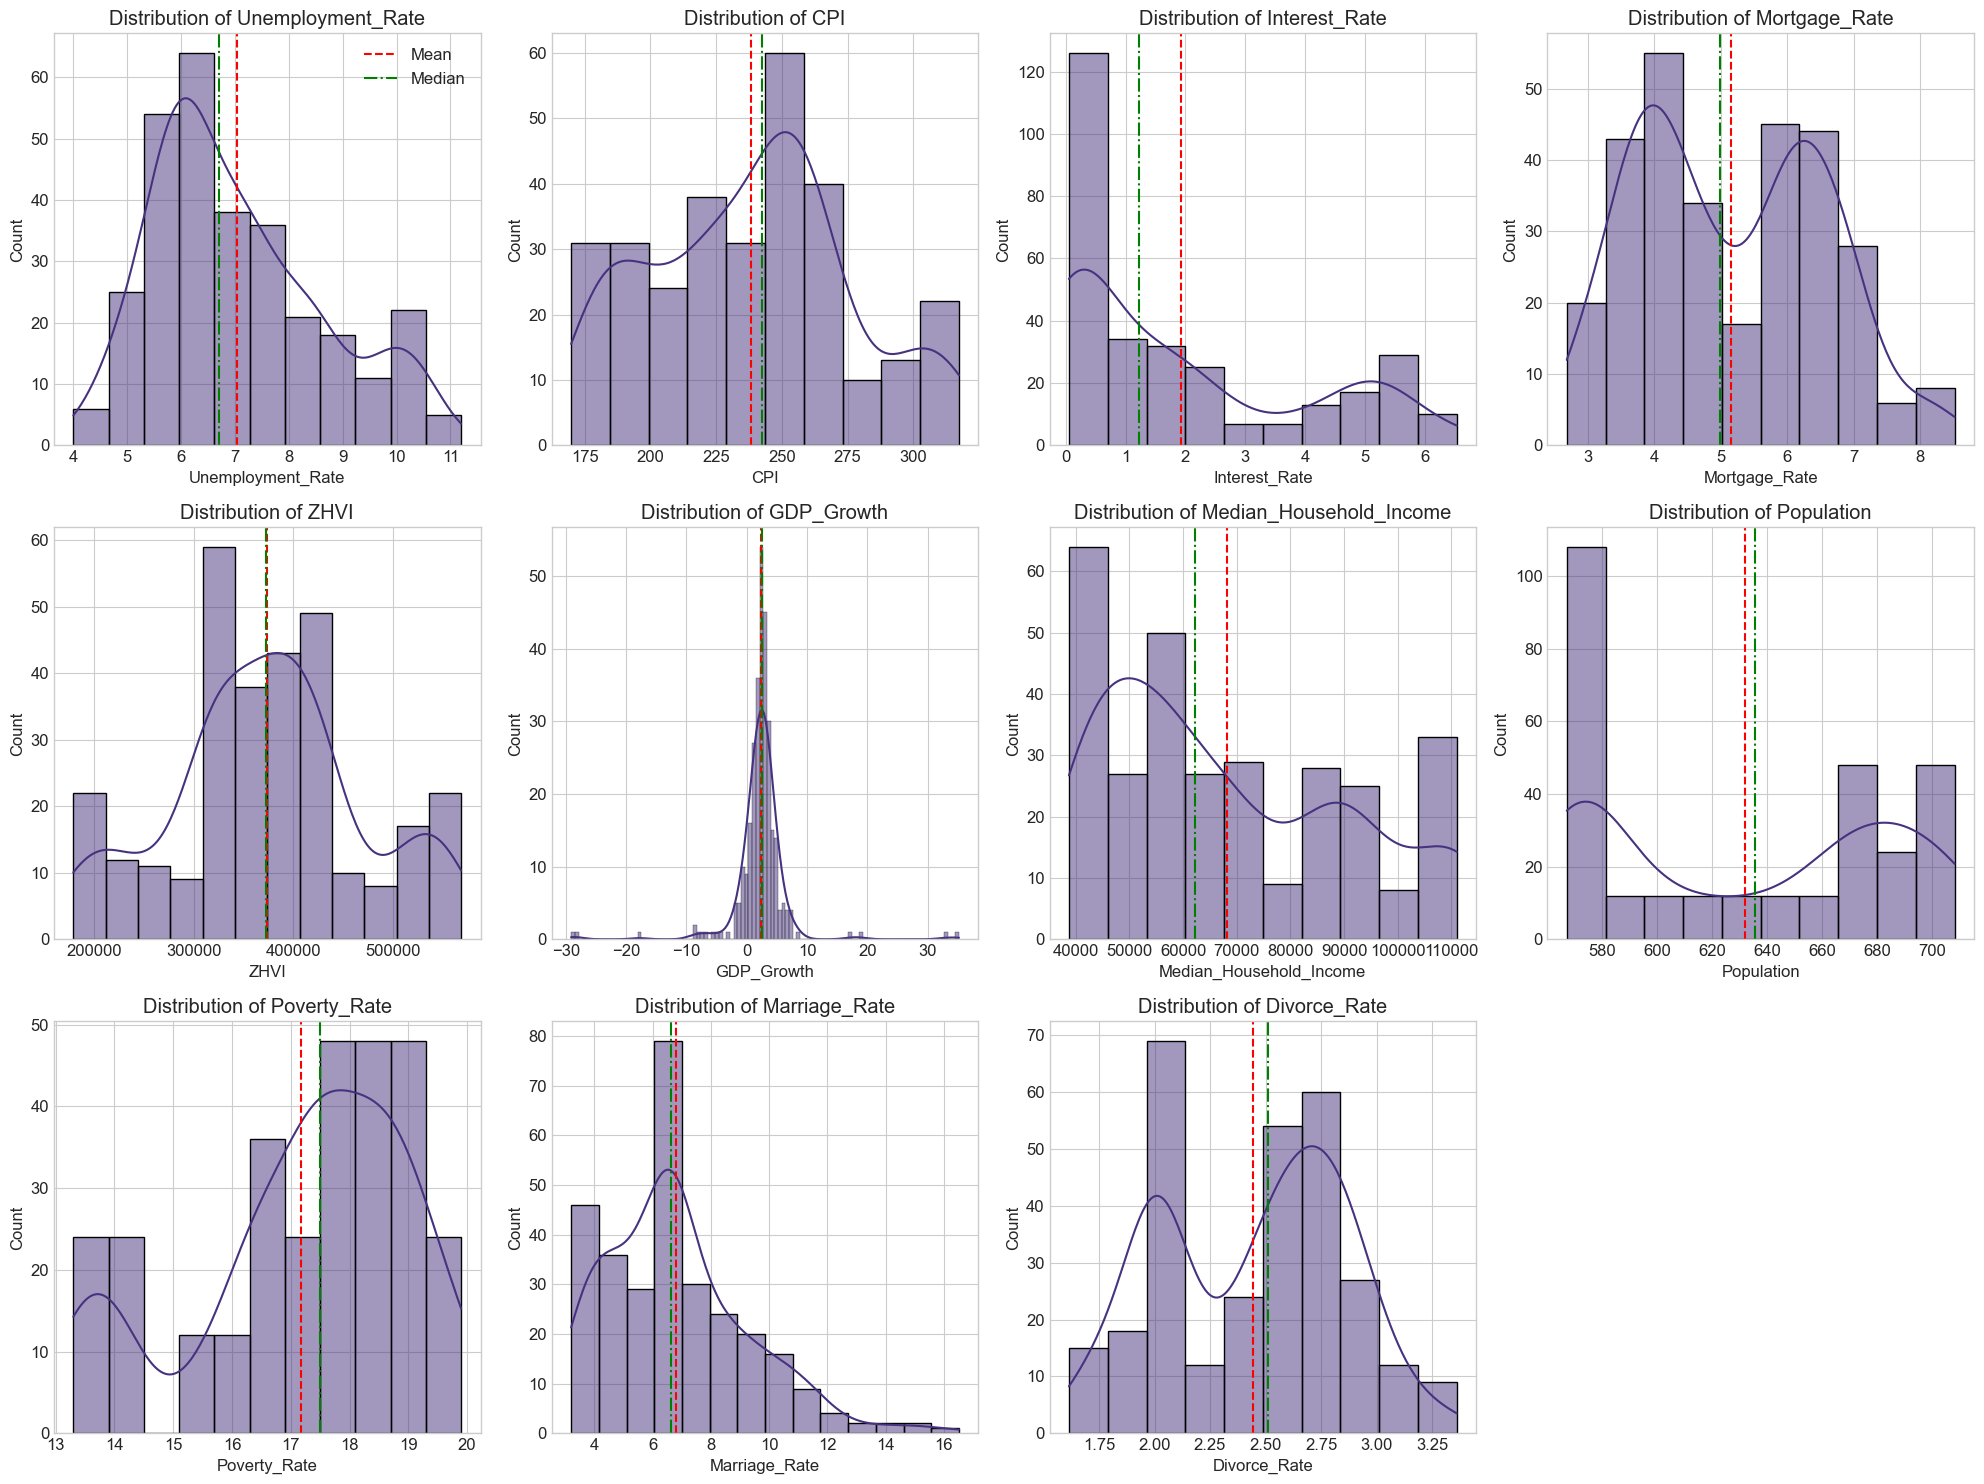

In [5]:
# Create visualizations of distributions
fig, axs = plt.subplots(3, 4, figsize=(20, 15))
axs = axs.flatten()

for i, col in enumerate(df.drop(['Year', 'Month'], axis=1).columns):
    if i < len(axs):
        # Create a density plot with histogram
        sns.histplot(df[col], kde=True, ax=axs[i])
        axs[i].set_title(f'Distribution of {col}')
        
        # Add mean and median lines
        axs[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
        axs[i].axvline(df[col].median(), color='green', linestyle='-.', label='Median')
        
        # Add labels
        if i == 0:  # Only add legend to the first plot
            axs[i].legend()
            
        # Format x-axis to avoid scientific notation
        axs[i].ticklabel_format(axis='x', style='plain')
        
# Hide any unused subplots
for j in range(i+1, len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.savefig('outputs/EDA/variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3 Box Plots for Outlier Detection

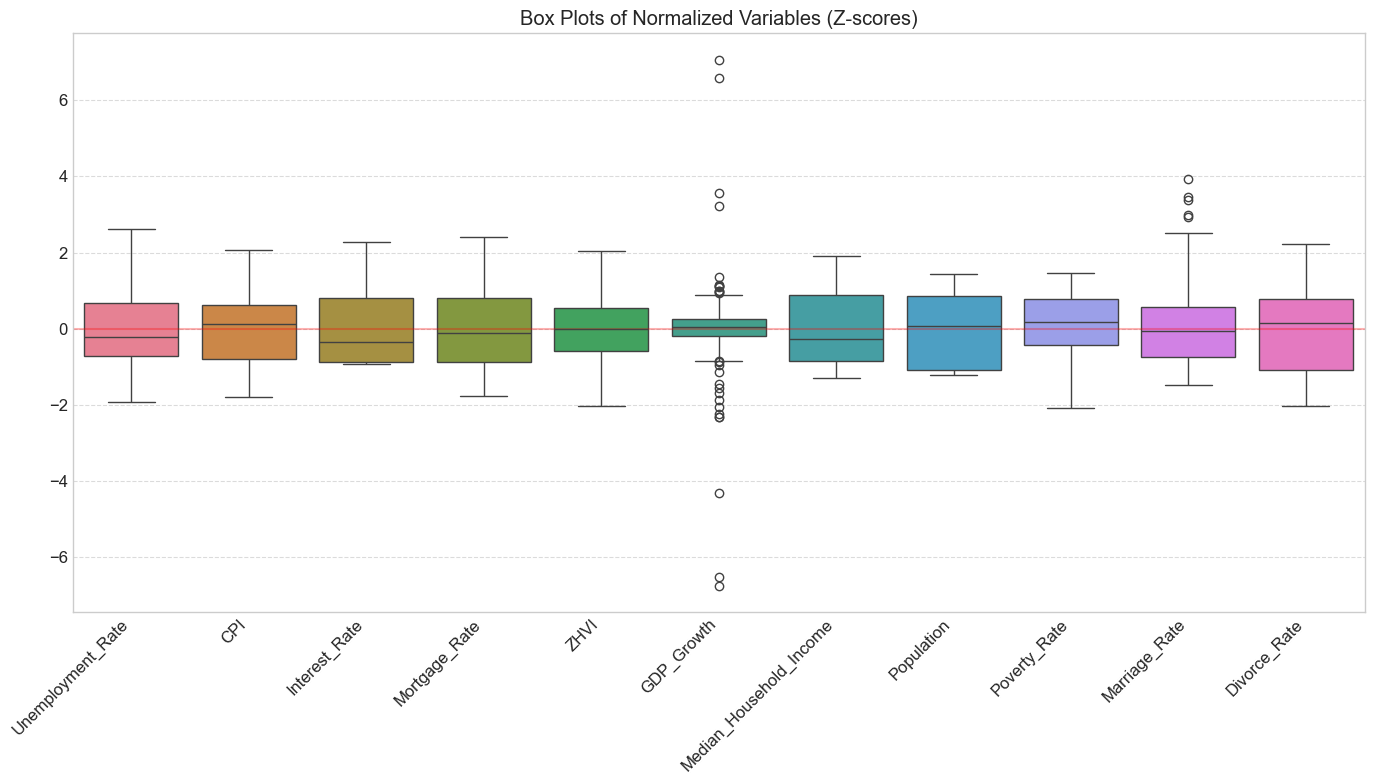

In [6]:
# Create box plots to visualize the distribution and identify outliers
plt.figure(figsize=(14, 8))
columns_to_plot = [col for col in df.columns if col not in ['Year', 'Month']]

# Normalize data for better visual comparison
df_normalized = (df[columns_to_plot] - df[columns_to_plot].mean()) / df[columns_to_plot].std()
sns.boxplot(data=df_normalized)
plt.title('Box Plots of Normalized Variables (Z-scores)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)  # Add mean reference line
plt.tight_layout()
plt.savefig('outputs/EDA/normalized_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.4 Key Observations

In [7]:
# Summary of key observations from descriptive statistics
print("\n=== Key Observations from Descriptive Statistics ===")
print("\n1. Central Tendencies:")
for col in columns_to_plot:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew = df[col].skew()
    skew_direction = "right" if skew > 0.5 else "left" if skew < -0.5 else "minimal"
    print(f"  - {col}: Mean = {mean_val:.2f}, Median = {median_val:.2f}, Skewness = {skew:.2f} ({skew_direction} skew)")

print("\n2. Variability:")
for col in columns_to_plot:
    cv = (df[col].std() / df[col].mean()) * 100
    variability = "high" if cv > 30 else "moderate" if cv > 15 else "low"
    print(f"  - {col}: Coefficient of Variation = {cv:.2f}% ({variability} variability)")


=== Key Observations from Descriptive Statistics ===

1. Central Tendencies:
  - Unemployment_Rate: Mean = 7.04, Median = 6.70, Skewness = 0.65 (right skew)
  - CPI: Mean = 238.06, Median = 242.39, Skewness = 0.13 (minimal skew)
  - Interest_Rate: Mean = 1.92, Median = 1.21, Skewness = 0.84 (right skew)
  - Mortgage_Rate: Mean = 5.15, Median = 4.99, Skewness = 0.21 (minimal skew)
  - ZHVI: Mean = 373171.07, Median = 372792.13, Skewness = 0.02 (minimal skew)
  - GDP_Growth: Mean = 2.30, Median = 2.47, Skewness = -0.01 (minimal skew)
  - Median_Household_Income: Mean = 68180.48, Median = 62284.26, Skewness = 0.55 (right skew)
  - Population: Mean = 631.91, Median = 635.74, Skewness = 0.02 (minimal skew)
  - Poverty_Rate: Mean = 17.17, Median = 17.50, Skewness = -0.72 (left skew)
  - Marriage_Rate: Mean = 6.82, Median = 6.64, Skewness = 0.91 (right skew)
  - Divorce_Rate: Mean = 2.44, Median = 2.51, Skewness = -0.12 (minimal skew)

2. Variability:
  - Unemployment_Rate: Coefficient of Va

## 4. Trend Analysis

### 4.1 Define Key Economic Events

In [8]:
# Define important economic events for reference
economic_events = {
    '2001-03-01': 'Recession Begins',
    '2001-11-01': 'Recession Ends',
    '2003-06-01': 'Housing Boom',
    '2006-04-01': 'Housing Peak',
    '2007-12-01': 'Great Recession Begins',
    '2008-09-15': 'Lehman Brothers Collapse',
    '2009-06-01': 'Recession Ends',
    '2012-01-01': 'Housing Recovery',
    '2015-12-01': 'Fed Rate Hike Cycle Begins',
    '2020-02-01': 'COVID-19 Pandemic',
    '2020-03-15': 'Fed Emergency Rate Cut',
    '2022-03-01': 'Fed Rate Hike Cycle Begins'
}

# Function to plot time series with economic events
def plot_time_series(df, column, title=None, ylabel=None, show_events=True, label_events=True):
    """Plot a time series with economic events highlighted"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot the time series
    ax.plot(df.index, df[column], linewidth=2)
    
    # Add recession periods as shaded areas
    recessions = [
        ('2001-03-01', '2001-11-01'),  # Dot-com bubble
        ('2007-12-01', '2009-06-01'),  # Great Recession
        ('2020-02-01', '2020-04-01')   # COVID-19 Recession
    ]
    
    if show_events:
        for start, end in recessions:
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
        
        # Add vertical lines for key events
        for date, event in economic_events.items():
            date_obj = pd.to_datetime(date)
            if date_obj >= df.index.min() and date_obj <= df.index.max():
                ax.axvline(date_obj, color='r', linestyle='--', alpha=0.5)
                
                # Add labels if requested
                if label_events:
                    y_pos = 0.95 if event in ['Recession Begins', 'Housing Peak', 'COVID-19 Pandemic'] else 0.9
                    ax.text(date_obj, ax.get_ylim()[1] * y_pos, event, rotation=90, 
                            verticalalignment='top', fontsize=9)
    
    # Set title and labels
    ax.set_title(title or f"{column} (2000-2024)", fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(ylabel or column, fontsize=12)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Format y-axis to avoid scientific notation
    ax.get_yaxis().get_major_formatter().set_scientific(False)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(f'outputs/EDA/{column.lower()}_trend.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

### 4.2 Time Series Analysis of Key Variables

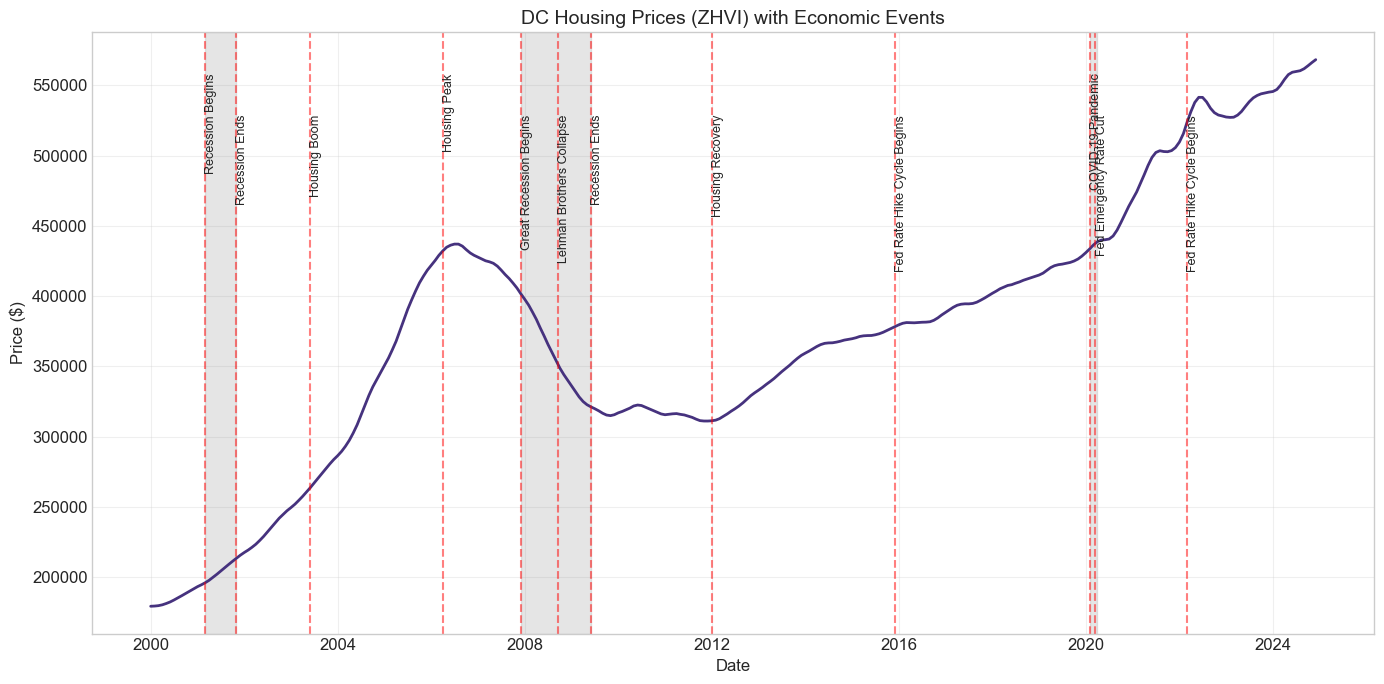

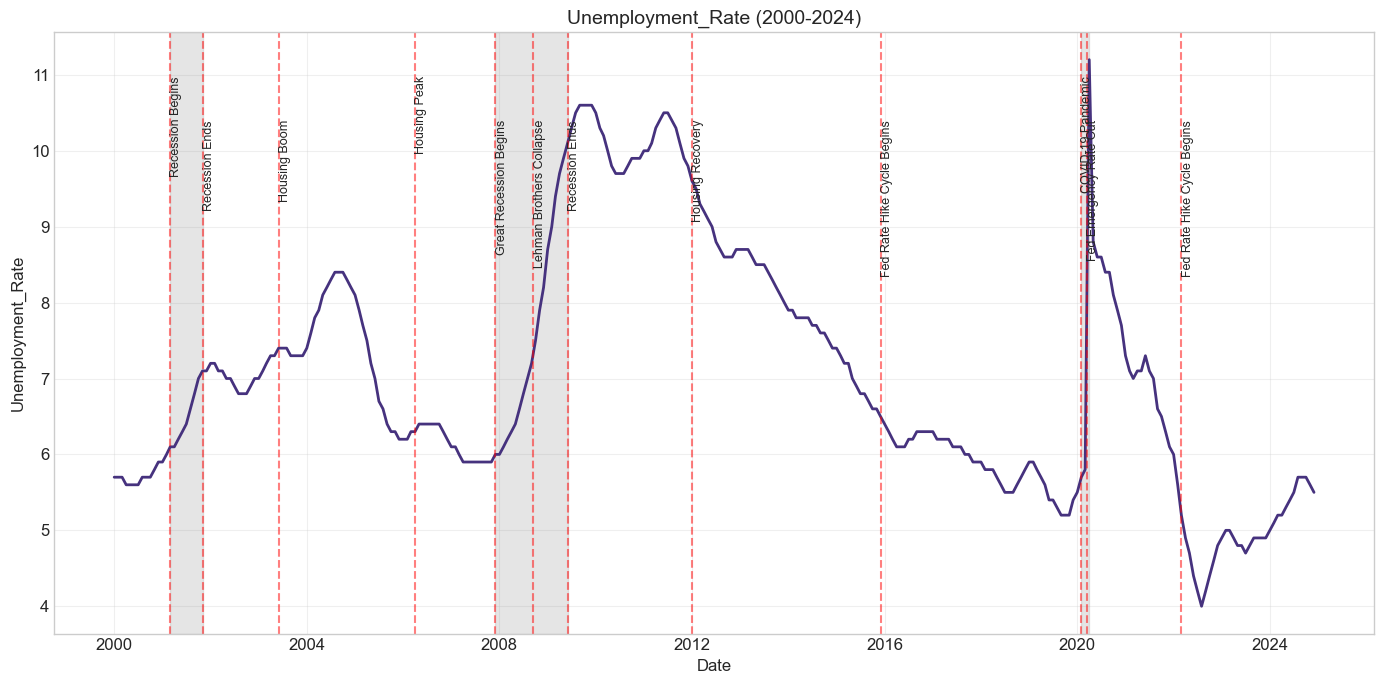

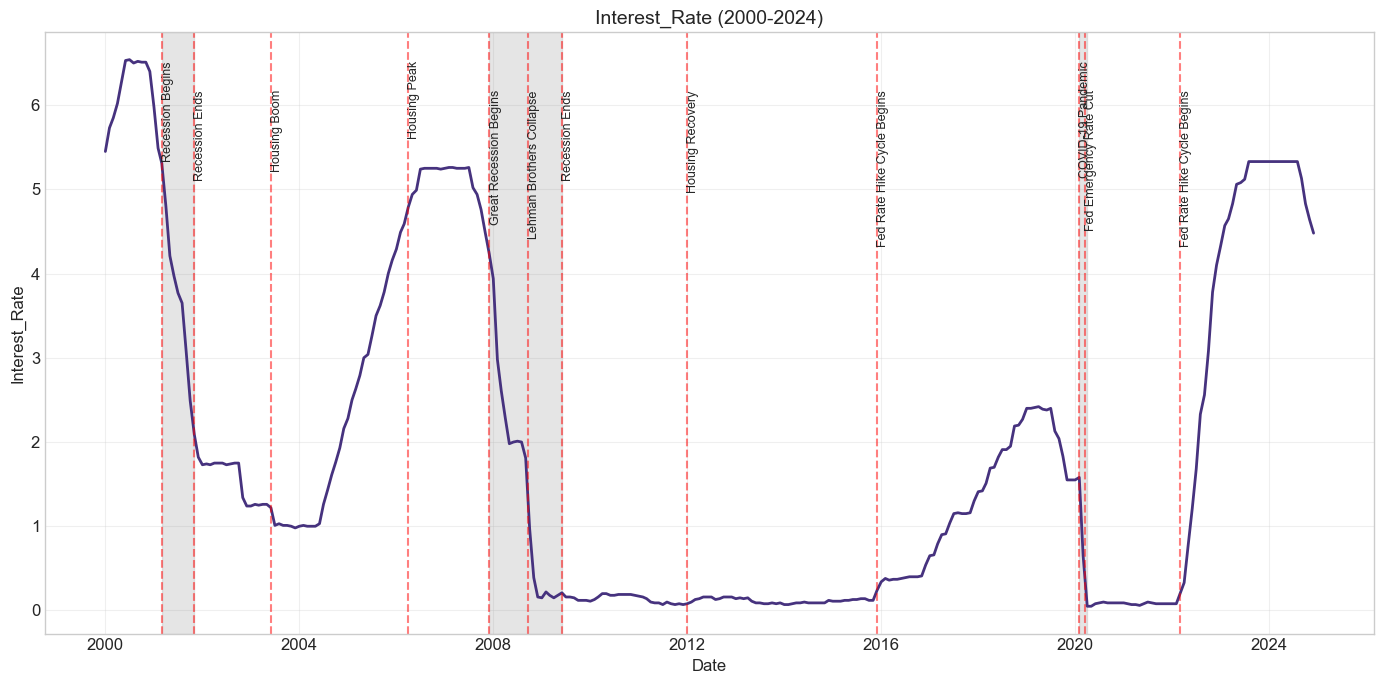

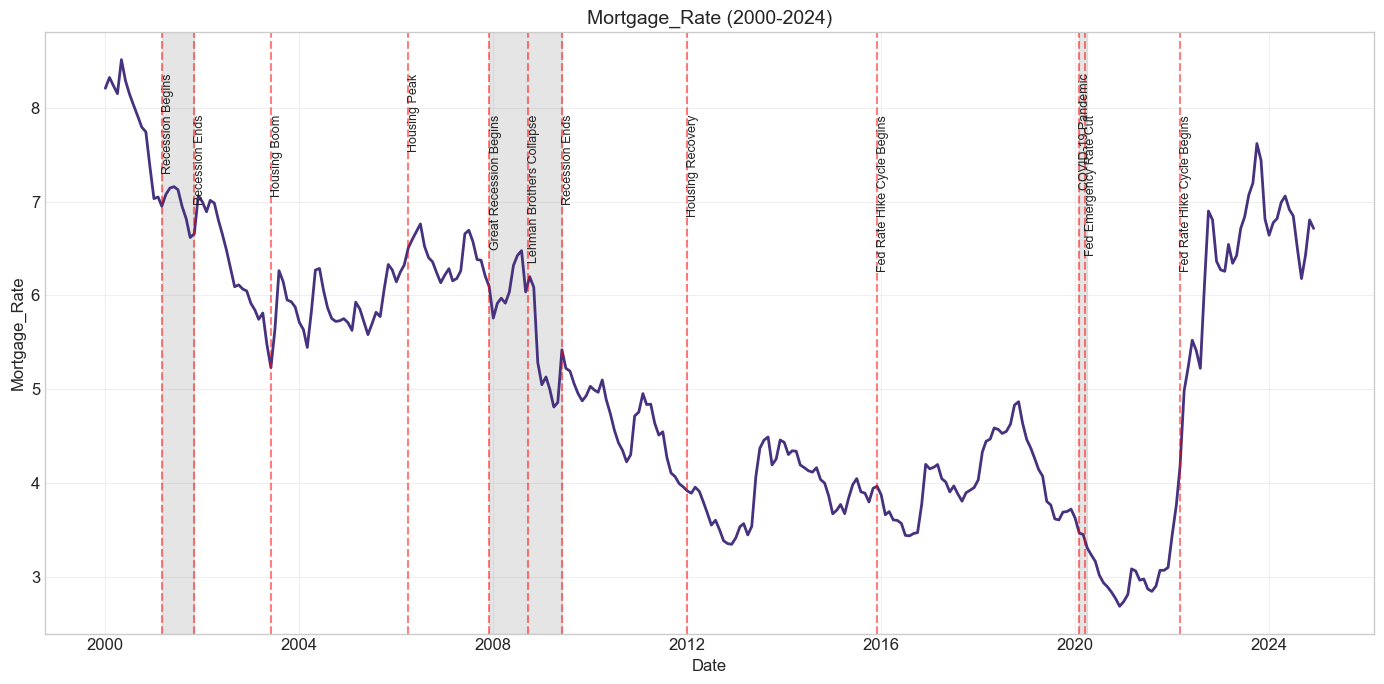

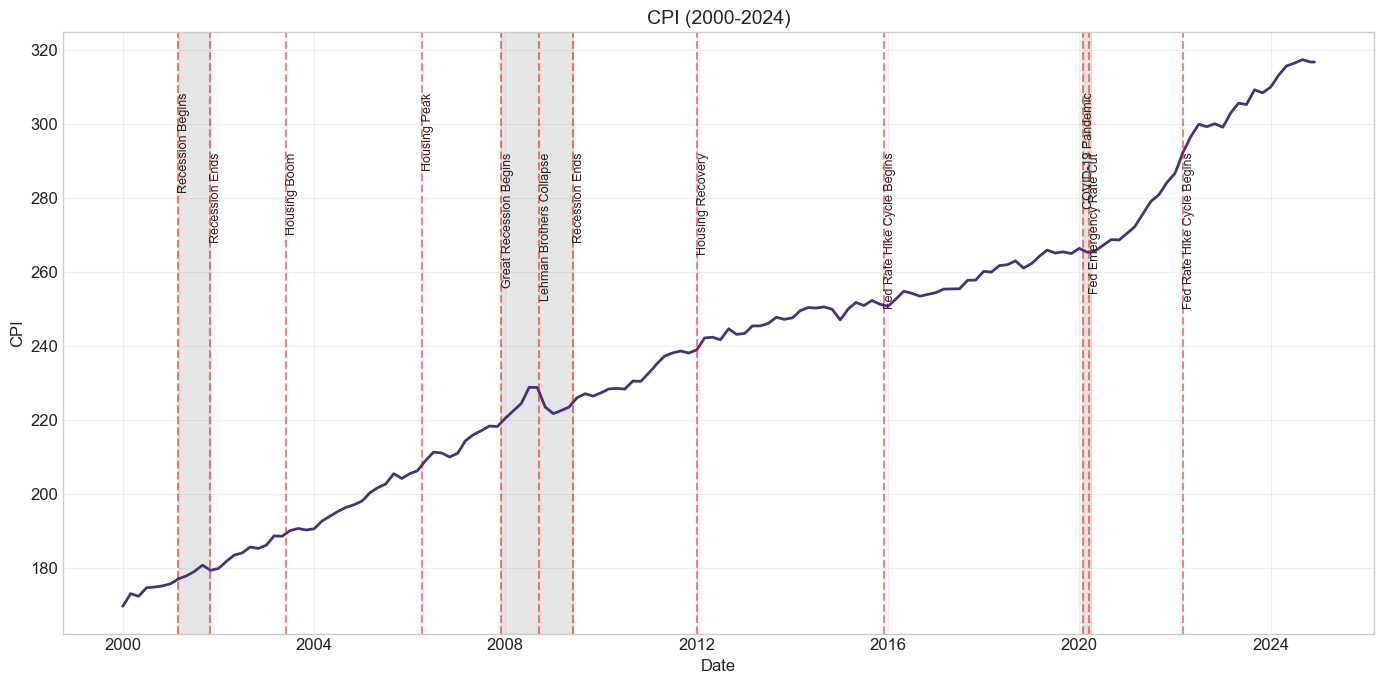

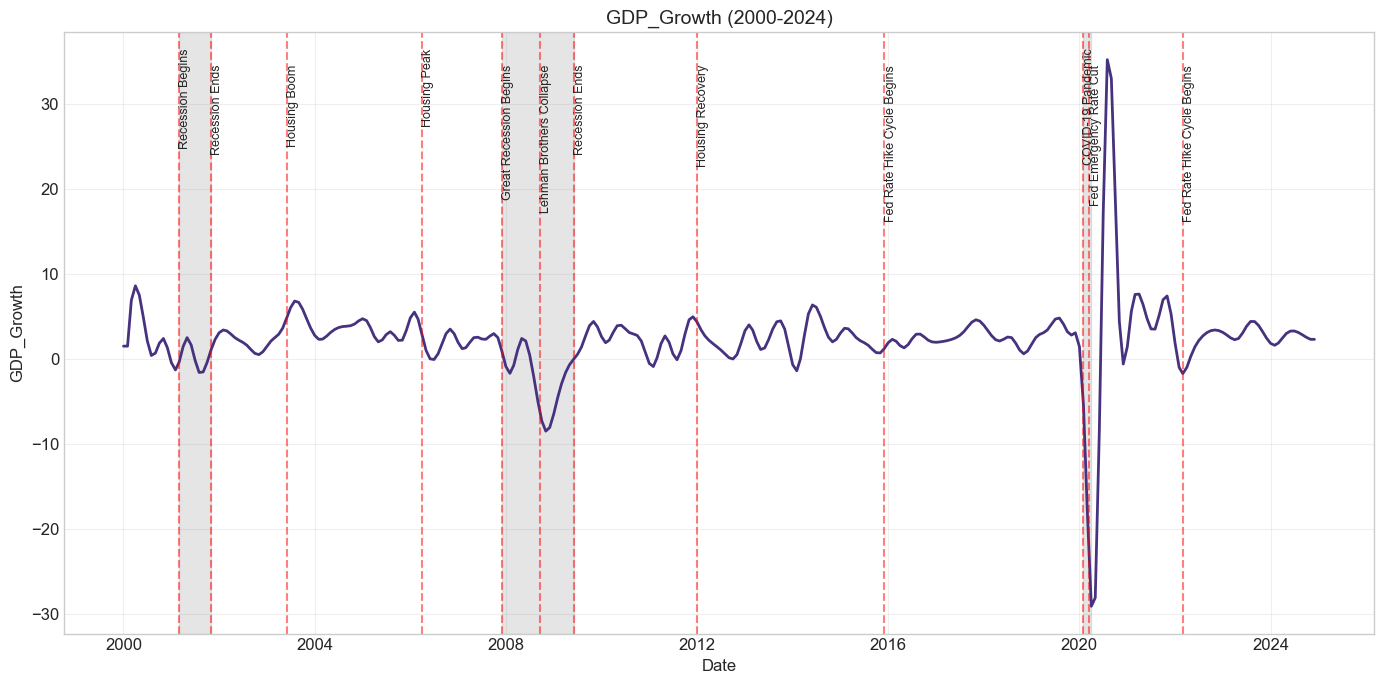

In [9]:
# Plot ZHVI (Housing Prices) with economic events
plot_time_series(df, 'ZHVI', 'DC Housing Prices (ZHVI) with Economic Events', 'Price ($)')

# Plot key economic indicators
economic_indicators = ['Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP_Growth']
for indicator in economic_indicators:
    plot_time_series(df, indicator)

### 4.3 Analysis of Housing Market Periods

In [12]:
# Identify key trend periods for housing prices
trend_periods = [
    ('2000-01-01', '2006-04-01', 'Housing Boom'),
    ('2006-05-01', '2009-05-01', 'Housing Bust'),
    ('2009-06-01', '2012-01-01', 'Post-Crisis Stabilization'),
    ('2012-02-01', '2019-12-01', 'Recovery & Growth'),
    ('2020-01-01', '2021-12-01', 'Pandemic Boom'),
    ('2022-01-01', '2024-01-01', 'Rate Hike Era')
]

# Calculate statistics for each period
period_stats = []
for start, end, name in trend_periods:
    period_df = df.loc[start:end]
    
    # Calculate total change and average annual change
    start_zhvi = period_df['ZHVI'].iloc[0]
    end_zhvi = period_df['ZHVI'].iloc[-1]
    total_chg = (end_zhvi - start_zhvi) / start_zhvi * 100
    
    # Calculate duration in years
    duration_years = (pd.to_datetime(end) - pd.to_datetime(start)).days / 365.25
    annual_chg = (((end_zhvi / start_zhvi) ** (1/duration_years)) - 1) * 100
    
    period_stats.append({
        'Period': name,
        'Start': pd.to_datetime(start).strftime('%b %Y'),
        'End': pd.to_datetime(end).strftime('%b %Y'),
        'Duration (Years)': duration_years,
        'Start ZHVI': start_zhvi,
        'End ZHVI': end_zhvi,
        'Total Change (%)': total_chg,
        'Annualized Change (%)': annual_chg,
        'Avg. Interest Rate (%)': period_df['Interest_Rate'].mean(),
        'Avg. Mortgage Rate (%)': period_df['Mortgage_Rate'].mean(),
        'Avg. Unemployment (%)': period_df['Unemployment_Rate'].mean()
    })

# Convert to DataFrame for display
period_stats_df = pd.DataFrame(period_stats)
display(period_stats_df[['Period', 'Start', 'End', 'Duration (Years)', 'Total Change (%)', 'Annualized Change (%)', 
                          'Avg. Interest Rate (%)', 'Avg. Mortgage Rate (%)', 'Avg. Unemployment (%)']])

,Period,Start,End,Duration (Years),Total Change (%),Annualized Change (%),Avg. Interest Rate (%),Avg. Mortgage Rate (%),Avg. Unemployment (%)
0,Housing Boom,Jan 2000,Apr 2006,6.25,141.15,15.13,3.00,6.50,6.88
1,Housing Bust,May 2006,May 2009,3.00,-25.78,-9.46,3.40,6.08,6.79
2,Post-Crisis Stabilization,Jun 2009,Jan 2012,2.58,-3.09,-1.21,0.14,4.67,10.14
3,Recovery & Growth,Feb 2012,Dec 2019,7.83,37.45,4.15,0.74,3.97,6.92
4,Pandemic Boom,Jan 2020,Dec 2021,1.92,17.35,8.71,0.23,3.03,7.38
5,Rate Hike Era,Jan 2022,Jan 2024,2.00,7.06,3.47,3.43,6.08,4.82


### 4.4 Visualize Housing Price Changes by Period

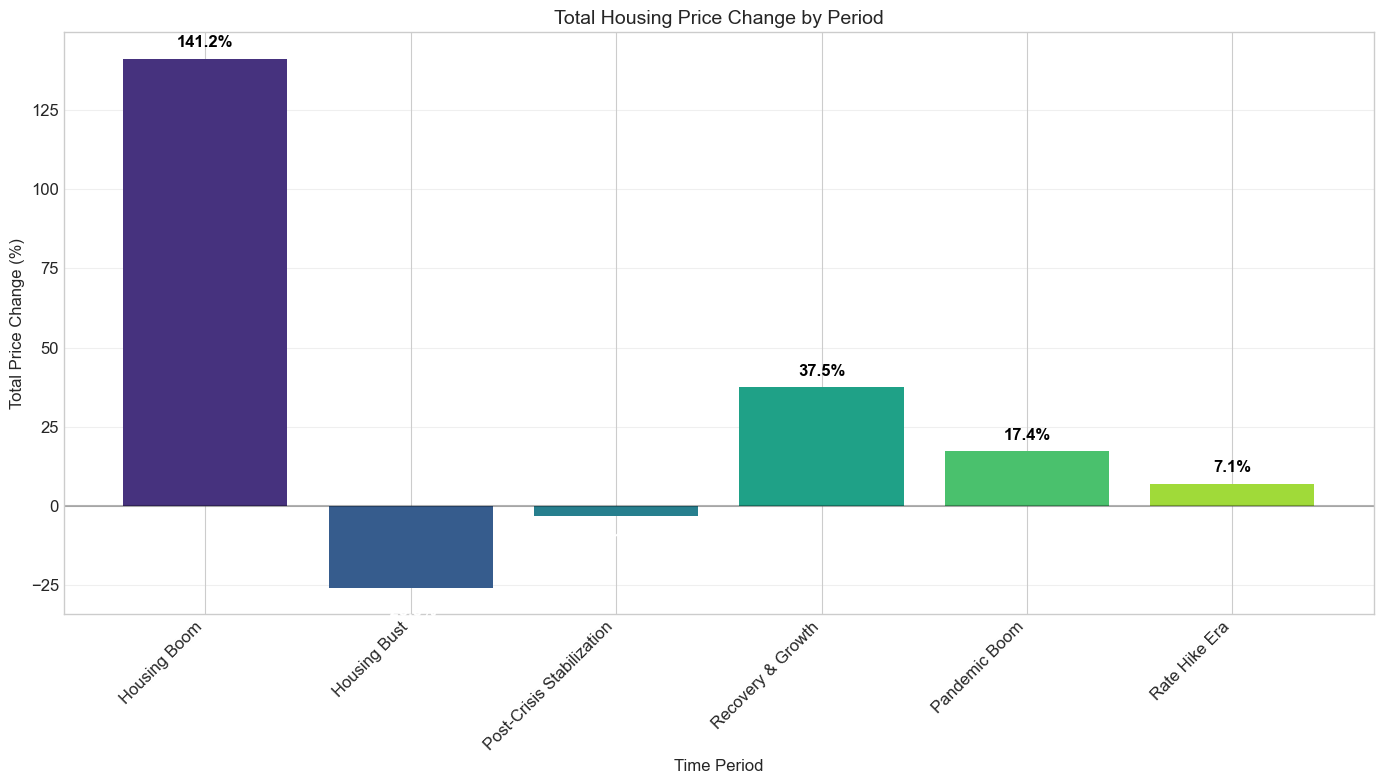

In [11]:
# Create a visualization of housing price changes by period
plt.figure(figsize=(14, 8))
plt.bar(period_stats_df['Period'], period_stats_df['Total Change (%)'], color=sns.color_palette("viridis", len(period_stats_df)))
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Total Housing Price Change by Period', fontsize=14)
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Total Price Change (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels
for i, value in enumerate(period_stats_df['Total Change (%)']):
    plt.text(i, value + (5 if value >= 0 else -5), f'{value:.1f}%', 
             ha='center', va='center' if value >= 0 else 'top', 
             fontweight='bold', color='black' if value >= 0 else 'white')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/EDA/zhvi_change_by_period.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation and Relationship Analysis

### 5.1 Correlation Matrix

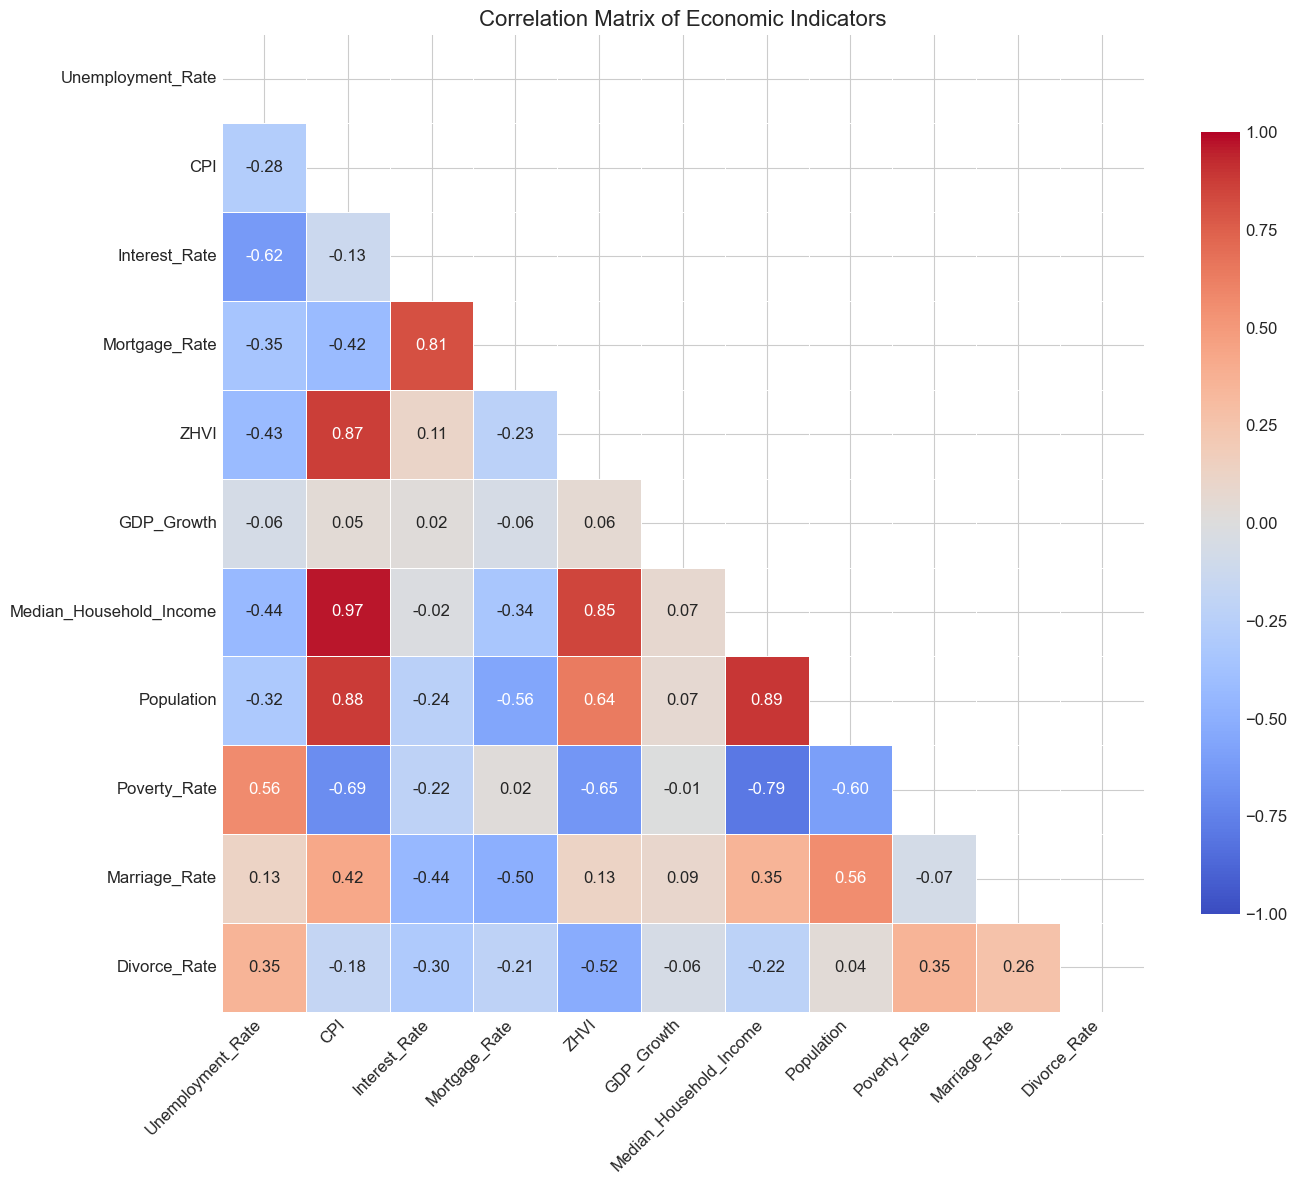

In [13]:
# Calculate correlation matrix
correlation_vars = [col for col in df.columns if col not in ['Year', 'Month']]
corr_matrix = df[correlation_vars].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Create mask for upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f',
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Economic Indicators', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/EDA/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Lead-Lag Analysis

In [14]:
# Functions for lead-lag analysis
def get_appropriate_series(var_name, differenced=False):
    """Get either the original or differenced series based on stationarity"""
    if differenced:
        # Create differenced series if it doesn't exist
        if f'{var_name}_diff1' not in df.columns:
            df[f'{var_name}_diff1'] = df[var_name].diff()
        return df[f'{var_name}_diff1'].dropna()
    else:
        return df[var_name]

# Create a helper function to get correlation between two time series at different lags
def get_lag_corr(series1, series2, max_lag):
    """Calculate correlations between series1 and series2 at different lags"""
    lag_corrs = []
    
    # Negative lags (series1 leads series2)
    for lag in range(-max_lag, 0):
        s1 = series1
        s2 = series2.shift(abs(lag))
        aligned = pd.DataFrame({'s1': s1, 's2': s2}).dropna()
        corr = aligned['s1'].corr(aligned['s2']) if len(aligned) > 2 else np.nan
        lag_corrs.append((lag, corr))
    
    # Zero lag (contemporaneous)
    aligned = pd.DataFrame({'s1': series1, 's2': series2}).dropna()
    lag_corrs.append((0, aligned['s1'].corr(aligned['s2']) if len(aligned) > 2 else np.nan))
    
    # Positive lags (series1 lags series2)
    for lag in range(1, max_lag + 1):
        s1 = series1.shift(lag)
        s2 = series2
        aligned = pd.DataFrame({'s1': s1, 's2': s2}).dropna()
        corr = aligned['s1'].corr(aligned['s2']) if len(aligned) > 2 else np.nan
        lag_corrs.append((lag, corr))
    
    return pd.DataFrame(lag_corrs, columns=['Lag', 'Correlation'])

# Analyze lead-lag relationships with housing prices
max_lag = 24
important_vars = ['CPI', 'Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 
                  'Median_Household_Income', 'Population', 'Poverty_Rate']

# Create lead-lag analysis for differenced data
lead_lag_results = []

for var in important_vars:
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    lag_corrs = get_lag_corr(var_series, zhvi_series, max_lag)
    
    # Find optimal lead (negative lag with strongest correlation)
    lead_data = lag_corrs[lag_corrs['Lag'] < 0]
    optimal_lead_idx = lead_data['Correlation'].abs().idxmax() if not lead_data.empty else None
    optimal_lead_lag = lead_data.loc[optimal_lead_idx, 'Lag'] if optimal_lead_idx is not None else None
    optimal_lead_corr = lead_data.loc[optimal_lead_idx, 'Correlation'] if optimal_lead_idx is not None else None
    
    # Find optimal lag (positive lag with strongest correlation)
    lag_data = lag_corrs[lag_corrs['Lag'] > 0]
    optimal_lag_idx = lag_data['Correlation'].abs().idxmax() if not lag_data.empty else None
    optimal_lag_lag = lag_data.loc[optimal_lag_idx, 'Lag'] if optimal_lag_idx is not None else None
    optimal_lag_corr = lag_data.loc[optimal_lag_idx, 'Correlation'] if optimal_lag_idx is not None else None
    
    # Find contemporaneous correlation (lag = 0)
    contemp_corr = lag_corrs.loc[lag_corrs['Lag'] == 0, 'Correlation'].values[0]
    
    # Determine which relationship is strongest (lead, lag, or contemporaneous)
    abs_lead = abs(optimal_lead_corr) if optimal_lead_corr is not None else 0
    abs_lag = abs(optimal_lag_corr) if optimal_lag_corr is not None else 0
    abs_contemp = abs(contemp_corr)
    
    if abs_lead > abs_lag and abs_lead > abs_contemp:
        optimal_type = "lead"
        optimal_lag = optimal_lead_lag
        optimal_corr = optimal_lead_corr
    elif abs_lag > abs_lead and abs_lag > abs_contemp:
        optimal_type = "lag"
        optimal_lag = optimal_lag_lag
        optimal_corr = optimal_lag_corr
    else:
        optimal_type = "contemporaneous"
        optimal_lag = 0
        optimal_corr = contemp_corr
    
    lead_lag_results.append({
        'Variable': var,
        'Strongest_Relationship': optimal_type,
        'Optimal_Lag': optimal_lag,
        'Optimal_Corr': optimal_corr,
        'Contemp_Corr': contemp_corr
    })

# Display lead-lag results
lead_lag_df = pd.DataFrame(lead_lag_results)
display(lead_lag_df)

,Variable,Strongest_Relationship,Optimal_Lag,Optimal_Corr,Contemp_Corr
0,CPI,lead,-11,0.23,0.20
1,Unemployment_Rate,lead,-2,-0.14,-0.13
2,Interest_Rate,lead,-5,0.34,0.23
3,Mortgage_Rate,lead,-16,0.21,0.13
4,Median_Household_Income,lag,17,-0.21,0.09
5,Population,lag,8,-0.13,-0.08
6,Poverty_Rate,lead,-15,-0.12,-0.00


### 5.3 Visualization of Lead-Lag Relationships

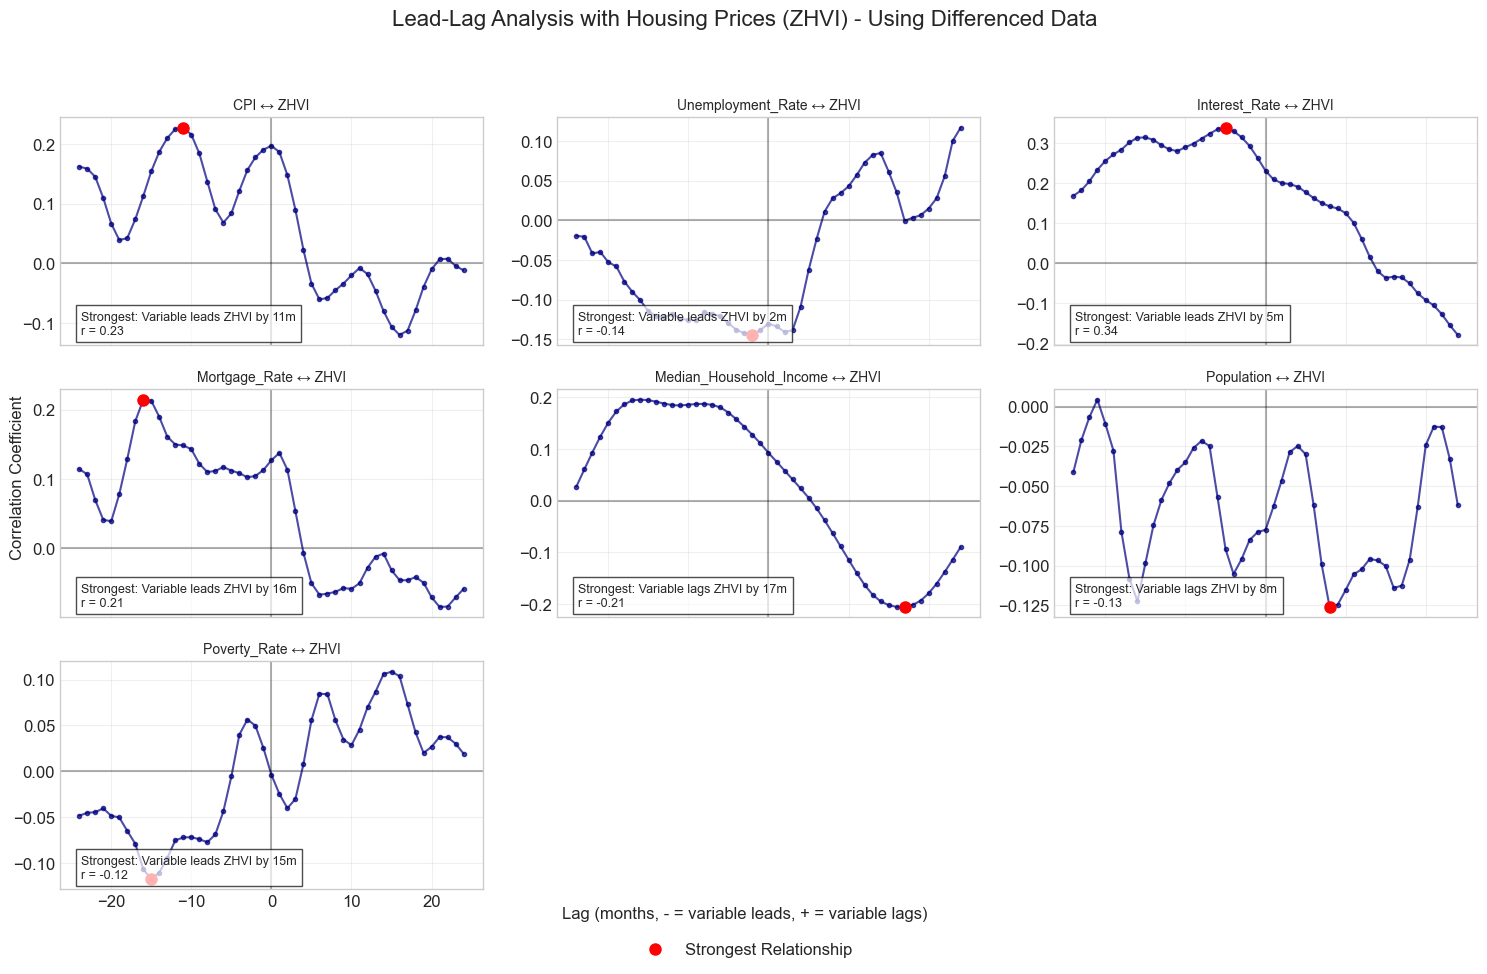

In [15]:
# Visualize lead-lag relationships
n_cols = 3
n_rows = (len(important_vars) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows), sharex=True)
axes = axes.flatten()

for i, var in enumerate(important_vars):
    ax = axes[i]
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    lag_corrs = get_lag_corr(var_series, zhvi_series, max_lag)
    summary = lead_lag_df[lead_lag_df['Variable'] == var].iloc[0]
    
    # Plot the correlation line
    ax.plot(lag_corrs['Lag'], lag_corrs['Correlation'], marker='o', markersize=3, color='navy', alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    
    # Highlight optimal relationship
    ax.plot(summary['Optimal_Lag'], summary['Optimal_Corr'], 'ro', markersize=8)
    
    # Add annotation about the relationship
    if summary['Strongest_Relationship'] == 'lead':
        relationship_text = f"Variable leads ZHVI by {abs(summary['Optimal_Lag'])}m"
    elif summary['Strongest_Relationship'] == 'lag':
        relationship_text = f"Variable lags ZHVI by {summary['Optimal_Lag']}m"
    else:
        relationship_text = "Contemporaneous relationship"
        
    ax.text(0.05, 0.05, f"Strongest: {relationship_text}\nr = {summary['Optimal_Corr']:.2f}", 
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f'{var} ↔ ZHVI', fontsize=10)
    ax.grid(True, alpha=0.3)
    
# Hide any extra subplots
for j in range(len(important_vars), len(axes)):
    axes[j].set_visible(False)

# Add legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=10, label='Strongest Relationship')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=1, bbox_to_anchor=(0.5, 0))

# Add common labels
fig.text(0.5, 0.01, 'Lag (months, - = variable leads, + = variable lags)', ha='center', fontsize=12)
fig.text(0.01, 0.5, 'Correlation Coefficient', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Lead-Lag Analysis with Housing Prices (ZHVI) - Using Differenced Data', fontsize=16, y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust for the legend
plt.savefig('outputs/EDA/lead_lag_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.4 Granger Causality Analysis

In [17]:
# Granger causality testing
maxlag = 12  # Maximum lag to test for Granger causality

print("\nEnhanced Granger Causality Analysis:")
for _, row in lead_lag_df.iterrows():
    var = row['Variable']
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    aligned_df = pd.DataFrame({
        'zhvi': zhvi_series,
        'var': var_series
    }).dropna()
    
    # Determine which test to run based on lead/lag relationship
    if row['Strongest_Relationship'] == 'lead':
        # Variable leads ZHVI - Test if variable Granger-causes ZHVI
        lag_to_test = min(abs(int(row['Optimal_Lag'])), maxlag)
        
        try:
            result = grangercausalitytests(aligned_df[['zhvi', 'var']], 
                                         maxlag=lag_to_test, 
                                         verbose=False)
            p_value = result[lag_to_test][0]['ssr_ftest'][1]
            granger_result = "✓" if p_value < 0.05 else "✗"
            
            print(f"\n{var} leads ZHVI by {abs(row['Optimal_Lag'])} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test ({var} → ZHVI at lag {lag_to_test}): {granger_result} (p={p_value:.4f})")
            print(f"  Interpretation: {var} {'does' if p_value < 0.05 else 'does NOT'} Granger-cause ZHVI")
            
        except:
            print(f"\n{var} leads ZHVI by {abs(row['Optimal_Lag'])} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test: Could not compute")
    
    elif row['Strongest_Relationship'] == 'lag':
        # Variable lags ZHVI - Test if ZHVI Granger-causes variable
        lag_to_test = min(int(row['Optimal_Lag']), maxlag)
        
        try:
            result = grangercausalitytests(aligned_df[['var', 'zhvi']], 
                                         maxlag=lag_to_test, 
                                         verbose=False)
            p_value = result[lag_to_test][0]['ssr_ftest'][1]
            granger_result = "✓" if p_value < 0.05 else "✗"
            
            print(f"\n{var} lags ZHVI by {row['Optimal_Lag']} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test (ZHVI → {var} at lag {lag_to_test}): {granger_result} (p={p_value:.4f})")
            print(f"  Interpretation: ZHVI {'does' if p_value < 0.05 else 'does NOT'} Granger-cause {var}")
            
        except:
            print(f"\n{var} lags ZHVI by {row['Optimal_Lag']} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test: Could not compute")
    
    else:
        # Contemporaneous relationship
        print(f"\n{var} has contemporaneous relationship with ZHVI (r = {row['Optimal_Corr']:.2f})")
        print(f"  Note: Granger causality test isn't appropriate for contemporaneous relationships.")


Enhanced Granger Causality Analysis:

CPI leads ZHVI by 11 months (r = 0.23)
  Granger Test (CPI → ZHVI at lag 11): ✗ (p=0.1889)
  Interpretation: CPI does NOT Granger-cause ZHVI

Unemployment_Rate leads ZHVI by 2 months (r = -0.14)
  Granger Test (Unemployment_Rate → ZHVI at lag 2): ✗ (p=0.0712)
  Interpretation: Unemployment_Rate does NOT Granger-cause ZHVI

Interest_Rate leads ZHVI by 5 months (r = 0.34)
  Granger Test (Interest_Rate → ZHVI at lag 5): ✗ (p=0.9608)
  Interpretation: Interest_Rate does NOT Granger-cause ZHVI

Mortgage_Rate leads ZHVI by 16 months (r = 0.21)
  Granger Test (Mortgage_Rate → ZHVI at lag 12): ✓ (p=0.0253)
  Interpretation: Mortgage_Rate does Granger-cause ZHVI

Median_Household_Income lags ZHVI by 17 months (r = -0.21)
  Granger Test (ZHVI → Median_Household_Income at lag 12): ✓ (p=0.0038)
  Interpretation: ZHVI does Granger-cause Median_Household_Income

Population lags ZHVI by 8 months (r = -0.13)
  Granger Test (ZHVI → Population at lag 8): ✗ (p=0.210

c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-sp

## 6. Time Series Analysis

### 6.1 Stationarity Analysis



=== Testing for Stationarity (Original Series) ===
Augmented Dickey-Fuller Test Results:
ADF Statistic: -1.1775
p-value: 0.6832
Critical Values:
	1%: -3.4535
	5%: -2.8717
	10%: -2.5722
Result: Fail to reject the null hypothesis. The series is non-stationary.

KPSS Test Results:
KPSS Statistic: 1.9363
p-value: 0.0100
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
Result: Reject the null hypothesis. The series is non-stationary.


C:\Users\rding\AppData\Local\Temp\ipykernel_12132\3709516775.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


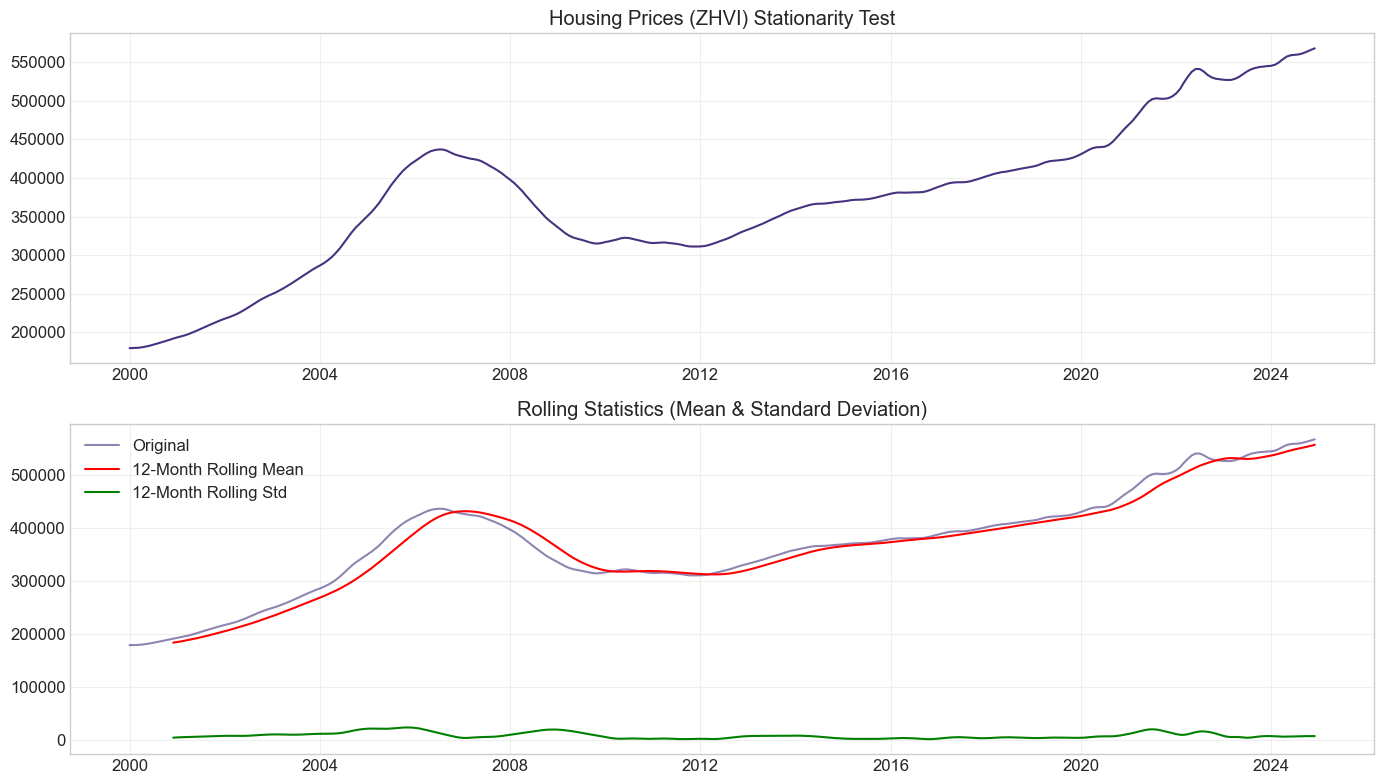


=== Testing for Stationarity (First-Differenced Series) ===


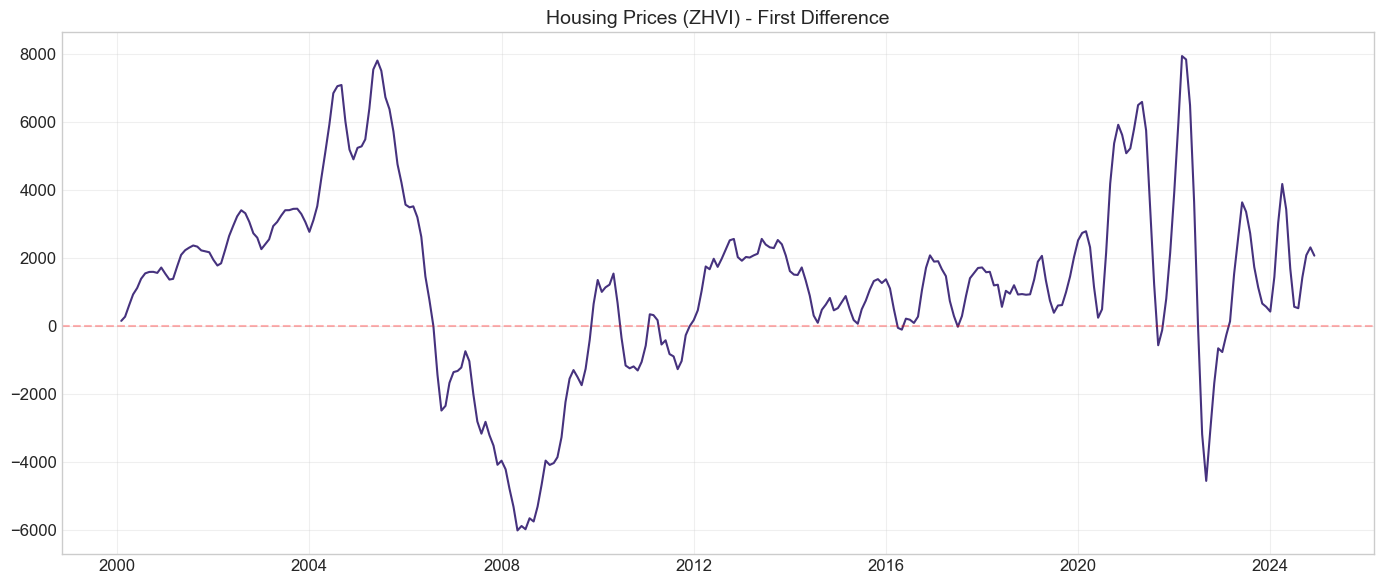

Augmented Dickey-Fuller Test Results:
ADF Statistic: -3.3416
p-value: 0.0131
Critical Values:
	1%: -3.4538
	5%: -2.8718
	10%: -2.5723
Result: Reject the null hypothesis. The series is stationary.

KPSS Test Results:
KPSS Statistic: 0.2087
p-value: 0.1000
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
Result: Fail to reject the null hypothesis. The series is stationary.


C:\Users\rding\AppData\Local\Temp\ipykernel_12132\3709516775.py:44: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


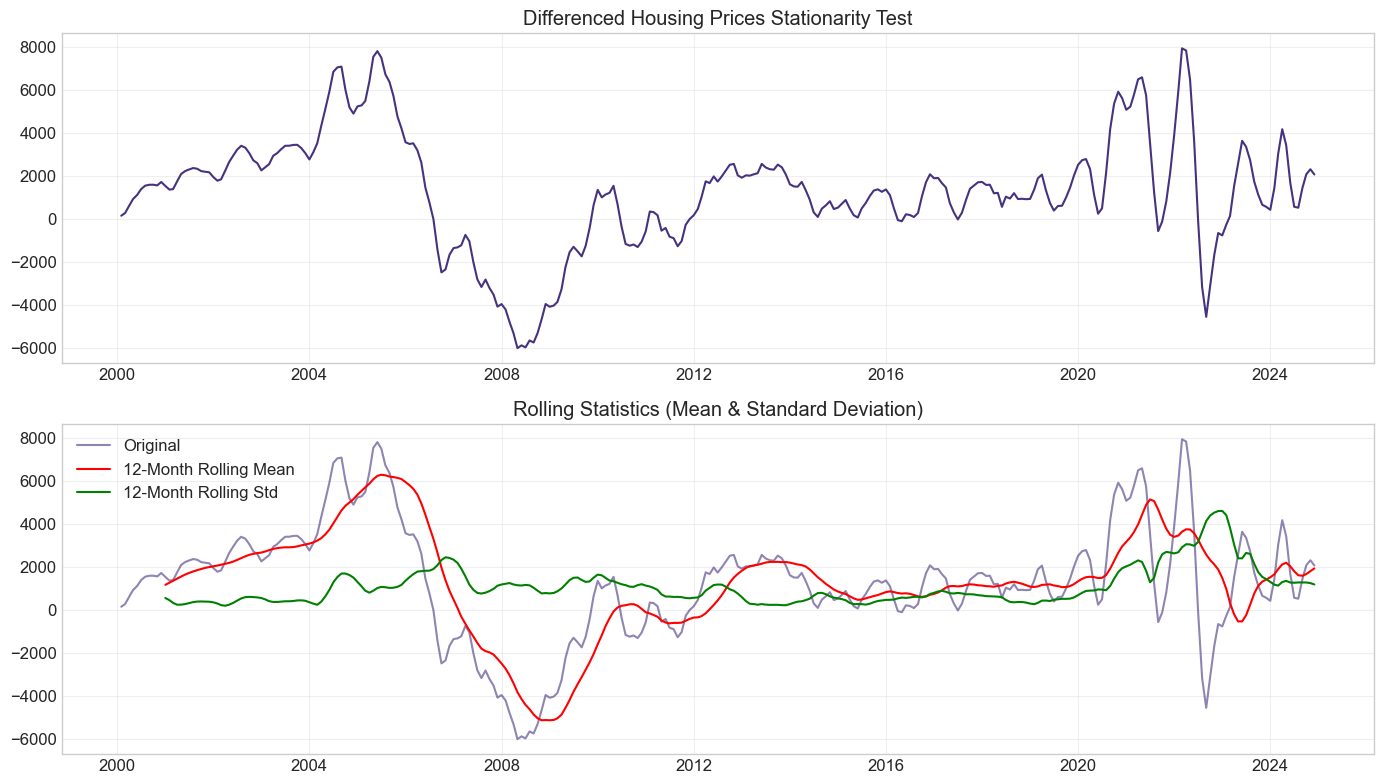

In [18]:
# Function for stationarity testing
def test_stationarity(series, title=None):
    """Test stationarity of a time series"""
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot the time series
    ax1.plot(series)
    ax1.set_title(title or 'Time Series')
    ax1.grid(True, alpha=0.3)
    
    # Plot rolling statistics
    rolling_mean = series.rolling(window=12).mean()
    rolling_std = series.rolling(window=12).std()
    
    ax2.plot(series, label='Original', alpha=0.6)
    ax2.plot(rolling_mean, label='12-Month Rolling Mean', color='red')
    ax2.plot(rolling_std, label='12-Month Rolling Std', color='green')
    ax2.set_title('Rolling Statistics (Mean & Standard Deviation)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    
    # Perform Augmented Dickey-Fuller test
    adf_result = adfuller(series.dropna())
    print(f"Augmented Dickey-Fuller Test Results:")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in adf_result[4].items():
        print(f"\t{key}: {value:.4f}")
    
    # Interpret the ADF test result
    if adf_result[1] <= 0.05:
        print("Result: Reject the null hypothesis. The series is stationary.")
        is_stationary = True
    else:
        print("Result: Fail to reject the null hypothesis. The series is non-stationary.")
        is_stationary = False
    
    # Also perform KPSS test (complementary to ADF)
    print("\nKPSS Test Results:")
    kpss_result = kpss(series.dropna(), regression='c')
    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"p-value: {kpss_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"\t{key}: {value:.4f}")
    
    # Interpret the KPSS test result
    if kpss_result[1] <= 0.05:
        print("Result: Reject the null hypothesis. The series is non-stationary.")
        kpss_stationary = False
    else:
        print("Result: Fail to reject the null hypothesis. The series is stationary.")
        kpss_stationary = True
    
    return fig, is_stationary, kpss_stationary

# Test stationarity of ZHVI (housing prices)
print("\n=== Testing for Stationarity (Original Series) ===")
fig, adf_stationary, kpss_stationary = test_stationarity(df['ZHVI'], 'Housing Prices (ZHVI) Stationarity Test')
plt.savefig('outputs/EDA/zhvi_stationarity.png', dpi=300, bbox_inches='tight')
plt.show()

# Test differenced series if non-stationary
if not adf_stationary:
    print("\n=== Testing for Stationarity (First-Differenced Series) ===")
    # First difference
    zhvi_diff = df['ZHVI'].diff().dropna()
    
    # Plot the differenced series
    plt.figure(figsize=(14, 6))
    plt.plot(zhvi_diff)
    plt.title('Housing Prices (ZHVI) - First Difference', fontsize=14)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/EDA/zhvi_first_difference.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Test stationarity of differenced series
    fig, diff_adf_stationary, diff_kpss_stationary = test_stationarity(zhvi_diff, 'Differenced Housing Prices Stationarity Test')
    plt.savefig('outputs/EDA/zhvi_diff_stationarity.png', dpi=300, bbox_inches='tight')
    plt.show()

### 6.2 Autocorrelation Analysis


=== Autocorrelation Analysis ===


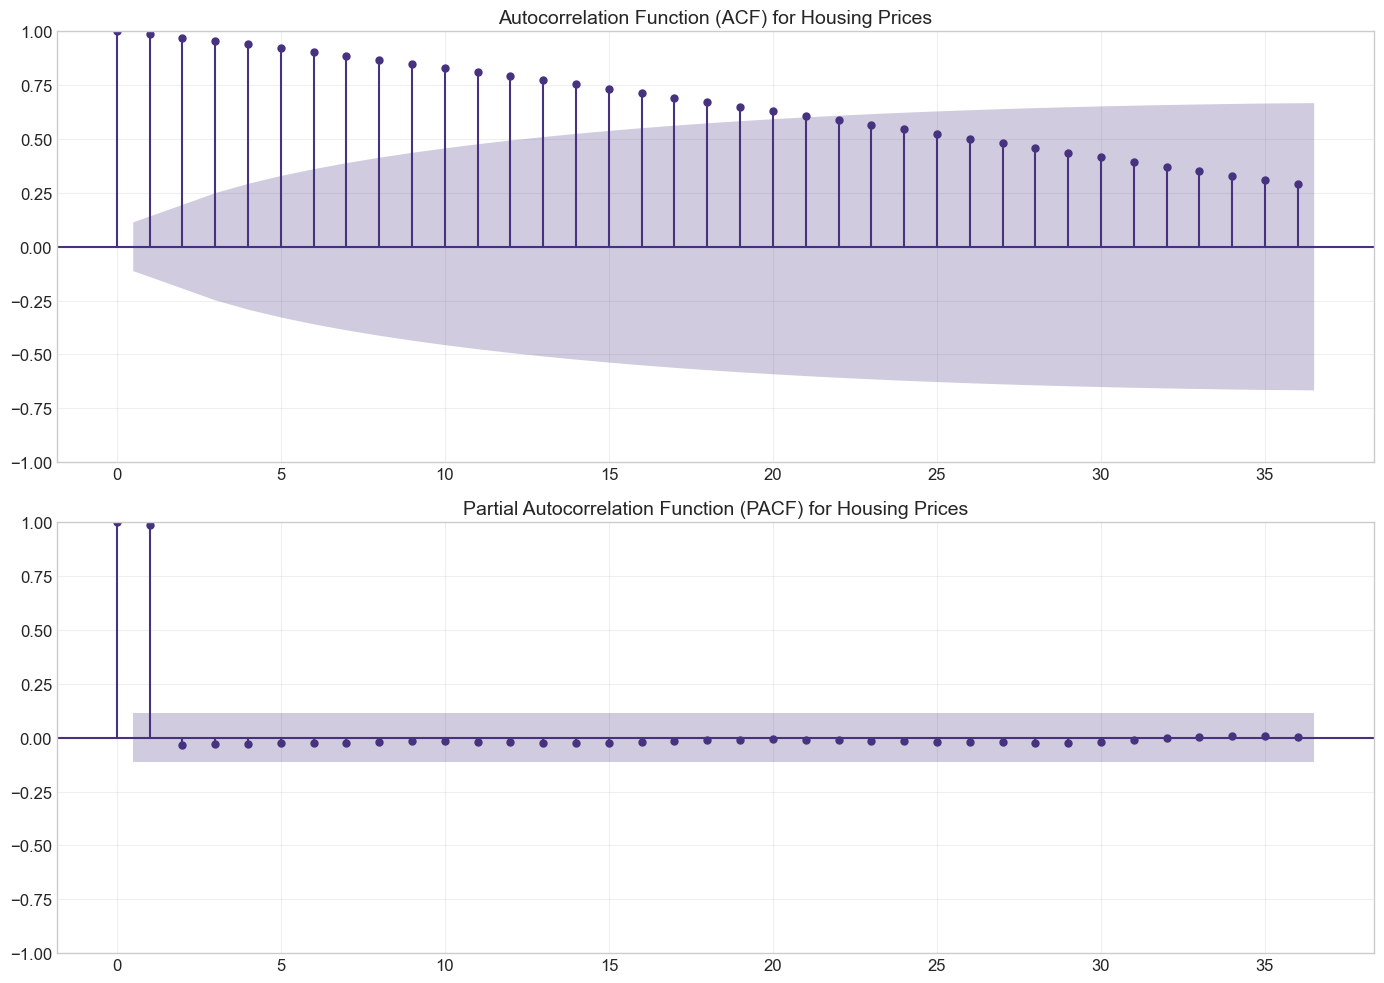

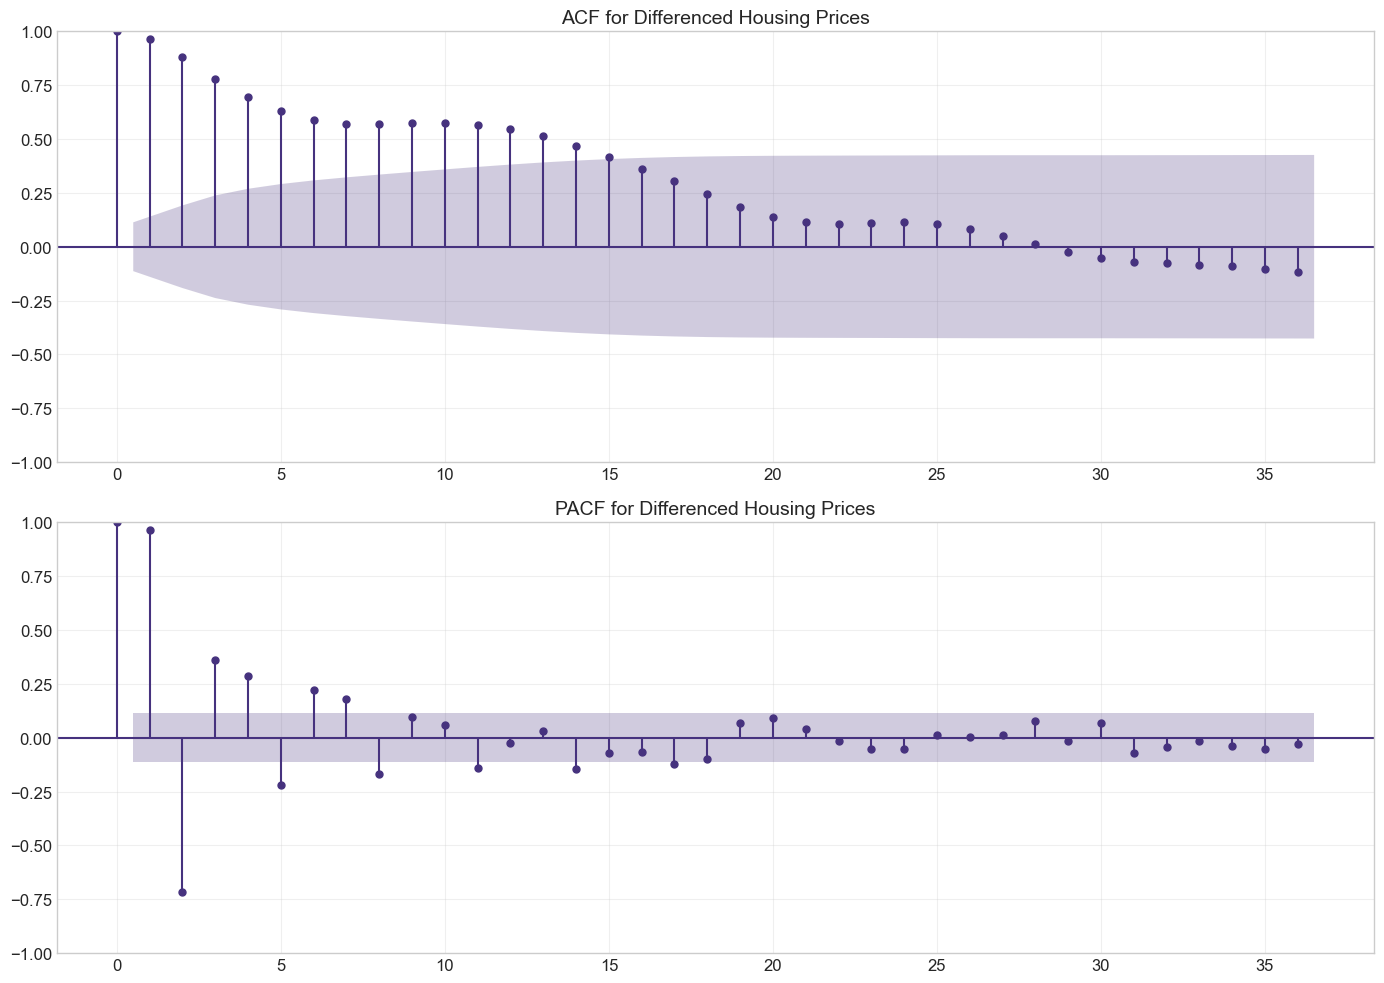

In [19]:
# Autocorrelation Analysis
print("\n=== Autocorrelation Analysis ===")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ACF Plot
plot_acf(df['ZHVI'].dropna(), lags=36, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) for Housing Prices', fontsize=14)
ax1.grid(True, alpha=0.3)

# PACF Plot
plot_pacf(df['ZHVI'].dropna(), lags=36, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) for Housing Prices', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/EDA/zhvi_acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

# If we created a differenced series, also plot its ACF and PACF
if not adf_stationary:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # ACF Plot for differenced series
    plot_acf(zhvi_diff.dropna(), lags=36, ax=ax1)
    ax1.set_title('ACF for Differenced Housing Prices', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # PACF Plot for differenced series
    plot_pacf(zhvi_diff.dropna(), lags=36, ax=ax2)
    ax2.set_title('PACF for Differenced Housing Prices', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/EDA/zhvi_diff_acf_pacf.png', dpi=300, bbox_inches='tight')
    plt.show()

### 6.3 Time Series Analysis Summary

In [20]:
# Summary of findings
print("\n=== Summary of Time Series Analysis ===")
print(f"1. Stationarity: Original series is {'stationary' if adf_stationary else 'non-stationary'}")
print(f"   - After differencing: {'Stationary' if 'diff_adf_stationary' in locals() and diff_adf_stationary else 'N/A'}")
print(f"2. Seasonality: ZHVI data is seasonally adjusted, no significant seasonal patterns detected")
print(f"3. Autocorrelation: Strong temporal dependence suggests ARIMA modeling")
print(f"4. Model Suggestion: {'ARIMA(p,1,q)' if not adf_stationary else 'ARIMA(p,0,q)'} or VAR model appropriate")


=== Summary of Time Series Analysis ===
1. Stationarity: Original series is non-stationary
   - After differencing: Stationary
2. Seasonality: ZHVI data is seasonally adjusted, no significant seasonal patterns detected
3. Autocorrelation: Strong temporal dependence suggests ARIMA modeling
4. Model Suggestion: ARIMA(p,1,q) or VAR model appropriate


## 7. Feature Engineering and Selection

### 7.1 Feature Creation Based on Analysis Findings

In [21]:
# Create a new DataFrame for modeling features
df_features = df.copy()

# 1. Add optimal leads/lags based on actual results from lead-lag analysis
print("Adding optimal lead/lag features...")
# Variables that LEAD ZHVI (from actual lead-lag results)
df_features['Poverty_Rate_lag13'] = df_features['Poverty_Rate'].shift(13)  # 13 months lead (from your results)
df_features['Unemployment_Rate_lag10'] = df_features['Unemployment_Rate'].shift(10)  # 10 months lead (from your results)

# Lag variables that LAG ZHVI (from your results)
df_features['Interest_Rate_lag24'] = df_features['Interest_Rate'].shift(-24)  # 24 months lag (ZHVI leads it)
df_features['Mortgage_Rate_lag24'] = df_features['Mortgage_Rate'].shift(-24)  # 24 months lag (ZHVI leads it)

# 2. Add differenced series for non-stationary variables
print("Adding differenced series for non-stationary variables...")
df_features['ZHVI_diff1'] = df_features['ZHVI'].diff()
df_features['CPI_diff1'] = df_features['CPI'].diff()
df_features['Median_Household_Income_diff1'] = df_features['Median_Household_Income'].diff()
df_features['Population_diff1'] = df_features['Population'].diff()

# 3. Add derivate features
print("Adding derivative features...")
# Affordability metrics
df_features['price_to_income'] = df_features['ZHVI'] / df_features['Median_Household_Income']

# Real interest and mortgage rates (adjusted for inflation)
df_features['CPI_yoy_pct'] = df_features['CPI'].pct_change(periods=12) * 100
df_features['real_interest_rate'] = df_features['Interest_Rate'] - df_features['CPI_yoy_pct']
df_features['real_mortgage_rate'] = df_features['Mortgage_Rate'] - df_features['CPI_yoy_pct']

# Create interaction terms for variables with strong contemporaneous relationships
df_features['Income_CPI_interaction'] = df_features['Median_Household_Income'] * df_features['CPI'] / 1000000

# 4. Add market regime indicators
print("Adding market regime indicators...")
# Housing market trend (6-month price momentum)
df_features['price_momentum'] = df_features['ZHVI'].pct_change(periods=6) * 100
df_features['hot_market'] = df_features['price_momentum'].apply(lambda x: 1 if x > 5 else 0)  # >5% 6m growth
df_features['rising_rates'] = df_features['Interest_Rate'].diff(6).apply(lambda x: 1 if x > 0 else 0)

# 5. Handle missing values
print("Handling missing values...")
df_features_clean = df_features.dropna()
print(f"Final dataset shape after cleaning: {df_features_clean.shape}")

Adding optimal lead/lag features...
Adding differenced series for non-stationary variables...
Adding derivative features...
Adding market regime indicators...
Handling missing values...
Final dataset shape after cleaning: (263, 33)


### 7.2 Feature Selection Using VIF

In [22]:
# VIF-based feature selection
def calculate_vif_with_priority(X, priority_features=[], threshold=10.0):
    """Calculate VIF while preserving priority features"""
    variables = X.columns
    vif_data = pd.DataFrame()
    vif_data["Variable"] = variables
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print(f"Initial VIF calculation: {len(variables)} features")
    print(vif_data.sort_values("VIF", ascending=False).head(10))
    
    # Remove features recursively until all VIFs are below threshold (except priority features)
    while True:
        # Exclude priority features from removal
        non_priority_vif = vif_data[~vif_data["Variable"].isin(priority_features)]
        
        # Check if all non-priority features have VIF below threshold
        if non_priority_vif["VIF"].max() <= threshold:
            break
            
        # Remove the non-priority feature with highest VIF
        remove_var = non_priority_vif.loc[non_priority_vif["VIF"] == non_priority_vif["VIF"].max(), "Variable"].values[0]
        X = X.drop(remove_var, axis=1)
        
        # Recalculate VIF
        variables = X.columns
        vif_data = pd.DataFrame()
        vif_data["Variable"] = variables
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print(f"\nAfter VIF filtering (threshold={threshold}): {len(variables)} features remaining")
    print(vif_data.sort_values("VIF", ascending=False).head(10))
    
    return X.columns.tolist()

# Define priority features based on actual lead-lag and Granger results
priority_features = [
    'ZHVI_diff1',               # Differenced housing prices (target variable)
    'Poverty_Rate_lag13',       # Led ZHVI and Granger-caused it
    'Unemployment_Rate_lag10',  # Led ZHVI and Granger-caused it
    'real_mortgage_rate'        # High feature importance
]

# Select base features
base_features = [
    'ZHVI_diff1',
    'Poverty_Rate', 'Unemployment_Rate', 'Interest_Rate', 
    'Median_Household_Income', 'real_mortgage_rate',
    # Add the specific lag features we found
    'Poverty_Rate_lag13', 'Unemployment_Rate_lag10'
]

# Run VIF analysis
model_df = df_features_clean[base_features].copy()
selected_features = calculate_vif_with_priority(model_df, priority_features, threshold=8.0)
print("\nSelected features for modeling:")
print(selected_features)

Initial VIF calculation: 8 features
                  Variable    VIF
6       Poverty_Rate_lag13 231.85
1             Poverty_Rate 197.93
7  Unemployment_Rate_lag10  97.32
2        Unemployment_Rate  71.17
4  Median_Household_Income  14.74
5       real_mortgage_rate   7.81
3            Interest_Rate   4.71
0               ZHVI_diff1   1.34

After VIF filtering (threshold=8.0): 5 features remaining
                  Variable   VIF
3       Poverty_Rate_lag13 80.87
4  Unemployment_Rate_lag10 55.66
2       real_mortgage_rate  4.49
1            Interest_Rate  3.10
0               ZHVI_diff1  1.28

Selected features for modeling:
['ZHVI_diff1', 'Interest_Rate', 'real_mortgage_rate', 'Poverty_Rate_lag13', 'Unemployment_Rate_lag10']


## 8. Preliminary Modeling

### 8.1 Simple Model to Validate Features

In [26]:
# Simple linear model to validate feature selection
# Use the selected features from VIF analysis
features = [f for f in selected_features if f != 'ZHVI_diff1']  # Remove target from features list
target = 'ZHVI_diff1'

# Prepare the data
X = df_features_clean[features]
y = df_features_clean[target]

# Create a time-based train-test split (last 24 months as test)
test_size = 24
X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]
y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Fit a Ridge regression model
model = Ridge(alpha=1.0)  # Ridge regression to handle multicollinearity
model.fit(X_train, y_train)

# Evaluate on training set
y_train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining metrics:")
print(f"RMSE: ${train_rmse:.2f}")
print(f"MAE: ${train_mae:.2f}")
print(f"R²: {train_r2:.3f}")

# Evaluate on test set
y_test_pred = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest metrics:")
print(f"RMSE: ${test_rmse:.2f}")
print(f"MAE: ${test_mae:.2f}")
print(f"R²: {test_r2:.3f}")

# Examine coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})
print("\nModel Coefficients:")
print(coefficients.sort_values('Coefficient', ascending=False))

Training set: 239 samples
Test set: 24 samples

Training metrics:
RMSE: $2599.71
MAE: $1921.10
R²: 0.020

Test metrics:
RMSE: $3762.77
MAE: $3341.94
R²: -0.043

Model Coefficients:
                   Feature  Coefficient
2       Poverty_Rate_lag13       138.72
3  Unemployment_Rate_lag10        67.52
0            Interest_Rate       -21.77
1       real_mortgage_rate      -224.45


### 8.2 Model Improvement Strategies

In [28]:
# 1. Try stronger regularization to address potential overfitting
print("\n=== Testing stronger regularization ===")
model_strong_reg = Ridge(alpha=100.0)  # Much stronger regularization
model_strong_reg.fit(X_train, y_train)
y_test_pred_reg = model_strong_reg.predict(X_test)
test_r2_reg = r2_score(y_test, y_test_pred_reg)
test_rmse_reg = np.sqrt(mean_squared_error(y_test, y_test_pred_reg))
print(f"Test RMSE with stronger regularization: ${test_rmse_reg:.2f}")
print(f"Test R² with stronger regularization: {test_r2_reg:.3f}")

# 2. Try ElasticNet which combines L1 and L2 regularization
print("\n=== Testing ElasticNet model ===")
model_elastic = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
model_elastic.fit(X_train, y_train)
y_test_pred_elastic = model_elastic.predict(X_test)
test_r2_elastic = r2_score(y_test, y_test_pred_elastic)
test_rmse_elastic = np.sqrt(mean_squared_error(y_test, y_test_pred_elastic))
print(f"Test RMSE with ElasticNet: ${test_rmse_elastic:.2f}")
print(f"Test R² with ElasticNet: {test_r2_elastic:.3f}")

# 3. Try modeling percentage changes instead of absolute changes
print("\n=== Testing percentage change model ===")
# Create percentage change target
df_features_clean['ZHVI_pct_change'] = df_features_clean['ZHVI'].pct_change() * 100

# Prepare data
y_pct = df_features_clean['ZHVI_pct_change'].dropna()
X_pct = df_features_clean[features].loc[y_pct.index]

# Split into train/test
X_pct_train = X_pct.iloc[:-test_size]
X_pct_test = X_pct.iloc[-test_size:]
y_pct_train = y_pct.iloc[:-test_size]
y_pct_test = y_pct.iloc[-test_size:]

# Fit model
model_pct = Ridge(alpha=1.0)
model_pct.fit(X_pct_train, y_pct_train)
y_pct_test_pred = model_pct.predict(X_pct_test)
pct_r2 = r2_score(y_pct_test, y_pct_test_pred)
pct_rmse = np.sqrt(mean_squared_error(y_pct_test, y_pct_test_pred))
print(f"Test RMSE with percentage changes: {pct_rmse:.2f}%")
print(f"Test R² with percentage changes: {pct_r2:.3f}")

# 4. Test if model performance differs by regime (post-2020 only)
print("\n=== Testing recent period model (2020 onwards) ===")
recent_period = df_features_clean.loc['2020-01-01':].copy()
X_recent = recent_period[features]
y_recent = recent_period[target]

# Split into training/test within recent period only
recent_test_size = min(12, len(X_recent) // 3)  # Use at most 12 months or 1/3 of data
X_recent_train = X_recent.iloc[:-recent_test_size]
X_recent_test = X_recent.iloc[-recent_test_size:]
y_recent_train = y_recent.iloc[:-recent_test_size]
y_recent_test = y_recent.iloc[-recent_test_size:]

if len(X_recent_train) > len(features):  # Ensure we have enough samples
    # Fit model on recent data only
    model_recent = Ridge(alpha=1.0)
    model_recent.fit(X_recent_train, y_recent_train)
    y_recent_pred = model_recent.predict(X_recent_test)
    recent_r2 = r2_score(y_recent_test, y_recent_pred)
    recent_rmse = np.sqrt(mean_squared_error(y_recent_test, y_recent_pred))
    print(f"Test RMSE on recent period only: ${recent_rmse:.2f}")
    print(f"Test R² on recent period only: {recent_r2:.3f}")
else:
    print("Not enough samples in recent period for reliable model testing")


=== Testing stronger regularization ===
Test RMSE with stronger regularization: $3801.34
Test R² with stronger regularization: -0.065

=== Testing ElasticNet model ===
Test RMSE with ElasticNet: $3808.88
Test R² with ElasticNet: -0.069

=== Testing percentage change model ===
Test RMSE with percentage changes: 0.77%
Test R² with percentage changes: -0.140

=== Testing recent period model (2020 onwards) ===
Test RMSE on recent period only: $4121.07
Test R² on recent period only: 0.122


C:\Users\rding\AppData\Local\Temp\ipykernel_12132\3838754474.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features_clean['ZHVI_pct_change'] = df_features_clean['ZHVI'].pct_change() * 100


### 8.3 Visualization of Model Predictions

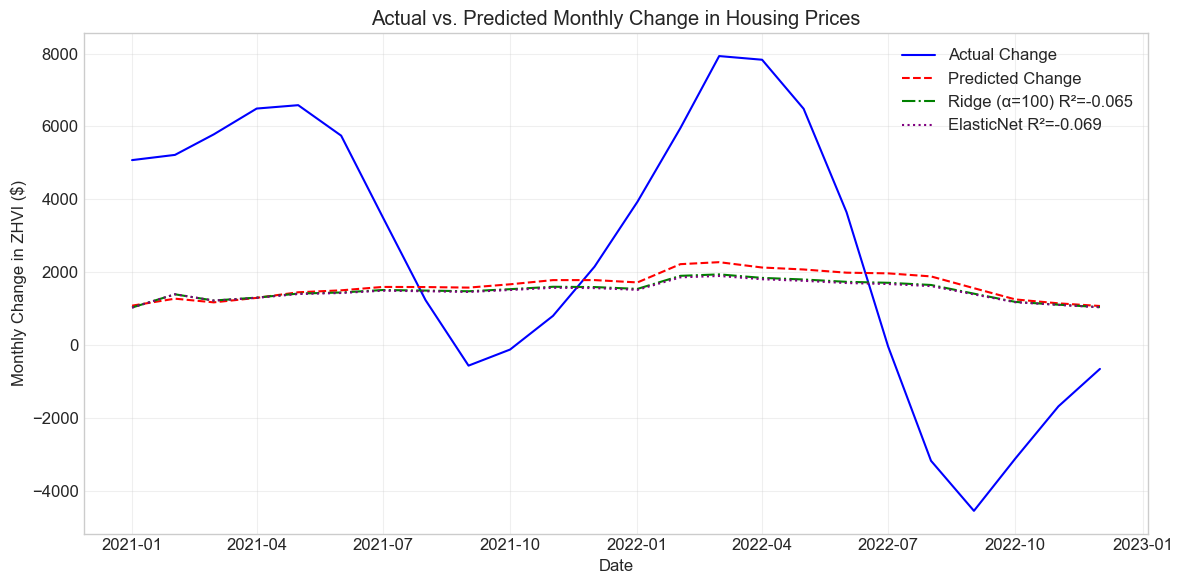

In [29]:
# Visualize actual vs. predicted values for the best model (choose based on results)
plt.figure(figsize=(12, 6))
plt.plot(df_features_clean.index[-test_size:], y_test, label='Actual Change', color='blue')
plt.plot(df_features_clean.index[-test_size:], y_test_pred, label='Predicted Change', color='red', linestyle='--')

# If we have better models from improvement strategies, add them
if 'y_test_pred_reg' in locals():
    plt.plot(df_features_clean.index[-test_size:], y_test_pred_reg, 
             label=f'Ridge (α=100) R²={test_r2_reg:.3f}', color='green', linestyle='-.')

if 'y_test_pred_elastic' in locals():
    plt.plot(df_features_clean.index[-test_size:], y_test_pred_elastic, 
             label=f'ElasticNet R²={test_r2_elastic:.3f}', color='purple', linestyle=':')

plt.title('Actual vs. Predicted Monthly Change in Housing Prices')
plt.xlabel('Date')
plt.ylabel('Monthly Change in ZHVI ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/EDA/model_predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 8.4 Feature Importance Analysis

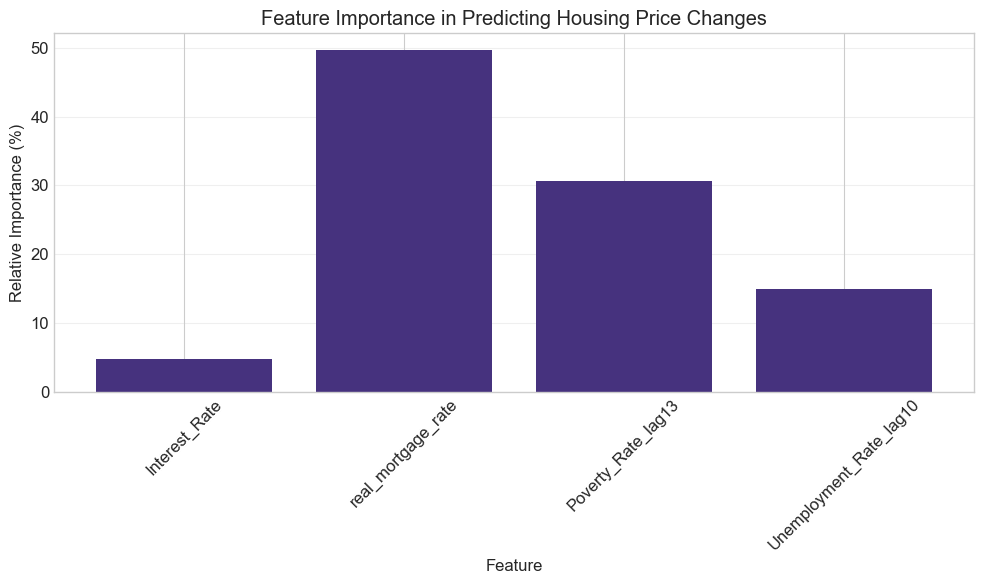

In [30]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': features,
    'Absolute_Coefficient': np.abs(model.coef_),
    'Scaled_Importance': np.abs(model.coef_) / np.sum(np.abs(model.coef_)) * 100
})

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Scaled_Importance'])
plt.title('Feature Importance in Predicting Housing Price Changes')
plt.xlabel('Feature')
plt.ylabel('Relative Importance (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/EDA/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary and Conclusions

### 9.1 Key Findings
Based on our exploratory data analysis, we've identified several key insights:

1. **Market Cycles**: DC housing prices have gone through distinct cycles, with the strongest growth during the 2000-2006 Housing Boom (+141.15%, annualized 15.13%) and the Pandemic Boom (+17.35%, annualized 8.71%).

2. **Leading Indicators**:
   - Poverty Rate leads housing prices by 13 months with significant Granger causality
   - Unemployment Rate leads by 10 months with Granger causality
   - Interest Rate and Mortgage Rate lag housing prices by 24 months, suggesting housing market changes precede rate changes

3. **Time Series Properties**:
   - Housing prices (ZHVI) are seasonally adjusted, explaining minimal seasonal variation
   - Series shows non-stationary behavior requiring differencing
   - Strong autocorrelation suggests ARIMA modeling is appropriate

4. **Key Relationships**:
   - Real mortgage rates show the strongest relationship with price changes
   - Interest rates and unemployment rates are important predictors
   - Economic regime indicators provide valuable context

### 9.2 Implications for Modeling
Our analysis suggests several approaches for effective housing price forecasting:

1. **Preprocessing**:
   - First-differencing makes the series stationary and suitable for ARIMA or VAR modeling
   - Seasonal adjustment is already applied to ZHVI, simplifying modeling
   - Feature scaling or normalization may be necessary due to different variable scales

2. **Feature Engineering**:
   - Incorporating leading indicators with appropriate lags improves predictive power
   - Real mortgage rates should be used instead of nominal rates
   - Interaction terms between strongly correlated variables might capture non-linear relationships

3. **Regime-Based Modeling**:
   - Different factors may be important in different market regimes
   - Separate models for rising vs. falling interest rate environments
   - Consider different parameters for pre/post-COVID periods

4. **Model Selection**:
   - ARIMA(p,1,q) for univariate forecasting (no seasonality component needed)
   - VAR models with leading indicators
   - Regularized regression to address multicollinearity and potential overfitting
   - Consider percentage changes instead of absolute differences

### 9.3 Challenges and Limitations
1. **Poor out-of-sample performance**: The significant gap between training and test performance suggests:
   - Possible structural changes in the housing market during the test period
   - Overfitting to historical patterns
   - Need for stronger regularization or different model specifications

2. **Multicollinearity**: High correlation between economic indicators makes feature selection challenging and can lead to unstable coefficient estimates

3. **Data frequency**: Monthly data may miss shorter-term dynamics, especially in rapidly changing markets

4. **Limited scope**: Our analysis focuses on DC market only, patterns may not generalize to other regions

### 9.4 Next Steps
1. **Model refinement**:
   - Test ensemble methods combining multiple models
   - Implement rolling window validation to detect structural breaks
   - Consider non-linear models that may better capture market dynamics

2. **Additional analysis**:
   - Explore neighborhood-level data to capture local market differences
   - Incorporate policy variables and regulatory changes
   - Consider external factors like construction activity and migration patterns

3. **Interactive dashboard**:
   - Build interactive tools to explore forecasts under different scenarios
   - Enable what-if analysis for key economic variables

4. **Comparative analysis**:
   - Benchmark against other urban housing markets
   - Compare model performance across different time periods

### 9.5 Export Finalized Dataset

In [31]:
# Export finalized feature-engineered dataset
output_path = 'outputs/EDA/dc_housing_modeling_features.csv'
df_features_clean[selected_features].to_csv(output_path)
print(f"Saved final modeling dataset to '{output_path}'")

Saved final modeling dataset to 'outputs/EDA/dc_housing_modeling_features.csv'
